# Predicción de tiro de baloncesto con IMUs


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import os
import pandas as pd
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import warnings
import os
import pandas as pd
from glob import glob
warnings.filterwarnings("ignore")

path_base = "/content/drive/MyDrive/Inercial"
data_path = "/content/drive/MyDrive/Inercial/data_inercial"
test_path = "/content/drive/MyDrive/Inercial/test"
data_csv_path = "/content/drive/MyDrive/Inercial/data.csv"

---

# 01 Recolección de datos

    Captura sincronizada con 3 IMUs (mano, antebrazo y brazo superior) para 10 lanzamientos y etiquetar el éxito o fallo del tiro.

    Calibrar los sensores al iniciar cada tiro respecto a una posición anatómica antes de cada ejecución.

## 1. Diseño Experimental

### 1.1 Captura de datos

Se realizó captura sincronizada utilizando **3 IMUs corporales** colocadas en:

- **Mano**
- **Antebrazo**
- **Brazo superior (bíceps)**

Cada participante ejecutó:

- **10 lanzamientos o más**
- Cada lanzamiento fue etiquetado como:
  - `0` = Falla
  - `1` = Encesta
  - `2` = Encesta Limpia


El objetivo es clasificar el resultado del tiro a partir de señales inerciales.

---

## 2. Configuración de Sensores

### 2.1 Orden e identificación de sensores

La columna `SensorId` identifica cada IMU:

| SensorId | Segmento corporal | IMU_ID |
|-----------|------------------|--------|
| 98        | Antebrazo        | 5      |
| 9F        | Bíceps           | 4      |
| 85        | Mano             | 2      |

---

## 3. Protocolo de Calibración

Antes de **cada tiro** se realizó:

1. Posición anatómica estándar (postura neutra).
2. Reinicio / referencia de orientación.
3. Registro del estado base para:
   - Compensar offset de acelerómetro.
   - Corregir drift del giroscopio.
   - Normalizar orientación inicial.

La calibración se ejecuta por lanzamiento para minimizar acumulación de error.

---

## 4. Errores

Debido a múltiples factores (fallos de Bluetooth, interferencia electromagnética y pérdida de conexión), no todos los lanzamientos registraron los tres sensores.

Se trabajará con datos faltantes, considerando válido cualquier lanzamiento que contenga al menos 1 sensor funcional.

---

## 5. Estrategia Frente a Datos Faltantes

Dado que el sistema presenta pérdidas parciales:

- Se acepta un mínimo de **1 IMU por lanzamiento**.
- Se deberá:
  - Identificar sensores disponibles por tiro.
  - Mantener consistencia temporal interna.
  - Aplicar técnicas de manejo de missing data:

El enfoque experimental no descarta muestras incompletas para evitar reducción significativa del dataset.

---

### Explorar sensores en todos los CSV

In [ ]:
# Listar archivos CSV en data_inercial
files = sorted(glob(os.path.join(data_path, "*.csv")))

print("Total archivos en data_inercial:", len(files))

Total archivos en data_inercial: 112


### Extraer sensores por archivo

In [ ]:
sensor_global_count = {}
sensor_per_file = {}

for f in files:
    df = pd.read_csv(f)

    if "SensorId" in df.columns:
        sensors = df["SensorId"].unique()
        sensor_per_file[os.path.basename(f)] = sensors

        for s in sensors:
            sensor_global_count[s] = sensor_global_count.get(s, 0) + 1

Crear DataFrame global de sensores

La columna `SensorId` identifica cada IMU:

| SensorId | Segmento corporal | IMU_ID |
|-----------|------------------|--------|
| 98        | Antebrazo        | 5      |
| 9F        | Bíceps           | 4      |
| 85        | Mano             | 2      |

Aparecen almenos 1 vez por intento

In [ ]:
sensor_global_df = pd.DataFrame.from_dict(
    sensor_global_count,
    orient="index",
    columns=["Cantidad_de_archivos"]
).sort_values("Cantidad_de_archivos", ascending=False)

print("Sensores globales:")
print(sensor_global_df)

Sensores globales:
   Cantidad_de_archivos
5                   102
2                    79
4                    27


Sensores más frecuentes en los archivos recolectados

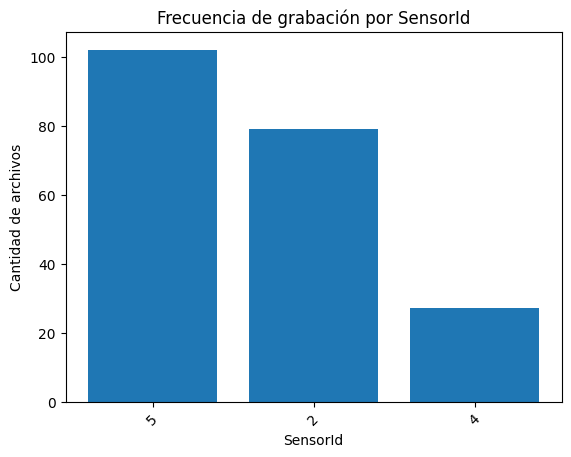

In [ ]:
plt.figure()
plt.bar(sensor_global_df.index.astype(str),
        sensor_global_df["Cantidad_de_archivos"])
plt.title("Frecuencia de grabación por SensorId")
plt.ylabel("Cantidad de archivos")
plt.xlabel("SensorId")
plt.xticks(rotation=45)
plt.show()

#### Consistencia del Sensor de Antebrazo (ID=98/5)

**Dato curioso:** El sensor del antebrazo (ID=98/5) fue el que más consistentemente grabó, con **102 de 111** lanzamientos registrados correctamente.

 Los sensores 5 (antebrazo) y 2 (mano) serán la base del modelo.

In [ ]:
import os
import pandas as pd
from glob import glob

data_info = pd.read_csv(data_csv_path)
files = glob(os.path.join(data_path, "*.csv"))

# Detectar sensores globales
all_sensors = set()

for f in files:
    df = pd.read_csv(f)
    if "SensorId" in df.columns:
        all_sensors.update(df["SensorId"].unique())

all_sensors = sorted(list(all_sensors))
print("Sensores detectados globalmente:", all_sensors)

Sensores detectados globalmente: [np.int64(2), np.int64(4), np.int64(5)]


In [ ]:
rows = []

for _, row in data_info.iterrows():

    student = row["student"]
    try_number = row["try"]
    shot_class = row["class"]
    file_name = row["name_file"]

    file_path = os.path.join(data_path, file_name)

    sensors_used = []

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        if "SensorId" in df.columns:
            sensors_used = df["SensorId"].unique().tolist()

    # Detectar sensores faltantes
    missing_sensors = list(set(all_sensors) - set(sensors_used))

    rows.append({
        "student": student,
        "try": try_number,
        "class": shot_class,
        "name_file": file_name,
        "sensores_detectados": sensors_used,
        "cantidad_sensores": len(sensors_used),
        "sensores_faltantes": missing_sensors
    })

try_sensor_df = pd.DataFrame(rows)

print(try_sensor_df.head())

  student  try  class      name_file sensores_detectados  cantidad_sensores  \
0  Mariel    1      0  Mariel_01.csv           [4, 2, 5]                  3   
1  Mariel    2      0  Mariel_02.csv           [4, 2, 5]                  3   
2  Mariel    3      1  Mariel_03.csv           [5, 4, 2]                  3   
3  Mariel    4      0  Mariel_04.csv           [4, 2, 5]                  3   
4  Mariel    5      0  Mariel_05.csv           [4, 5, 2]                  3   

  sensores_faltantes  
0                 []  
1                 []  
2                 []  
3                 []  
4                 []  


In [ ]:
incomplete_shots = try_sensor_df[try_sensor_df["cantidad_sensores"] < len(all_sensors)]

print("Tiros incompletos:")
print(incomplete_shots[["student", "try", "cantidad_sensores", "sensores_faltantes"]])

Tiros incompletos:
    student  try  cantidad_sensores sensores_faltantes
12   Mariel   13                  2                [4]
13   Mariel   14                  2                [4]
15   Mariel   16                  2                [4]
19     Eric    3                  2                [4]
21     Eric    5                  2                [4]
..      ...  ...                ...                ...
108  Norman    6                  1             [4, 5]
109  Norman    7                  1             [4, 5]
110  Norman    8                  1             [4, 5]
111  Norman    9                  1             [4, 5]
112  Norman   10                  1             [4, 5]

[87 rows x 4 columns]


In [ ]:
summary_student = try_sensor_df.groupby("student").agg({
    "cantidad_sensores": ["mean", "min", "max"],
})

print(summary_student)

        cantidad_sensores        
                     mean min max
student                          
Edgar            1.000000   1   1
Eric             2.307692   2   3
Ian              2.000000   2   2
Javier           2.500000   0   3
Juliet           1.888889   0   2
Mariel           2.823529   2   3
Norman           1.300000   1   3
Zarif            1.157895   1   2


Se identifica que se cuentaa en promedio con min información de un sensor en promedio de los intentos para cada alumno.

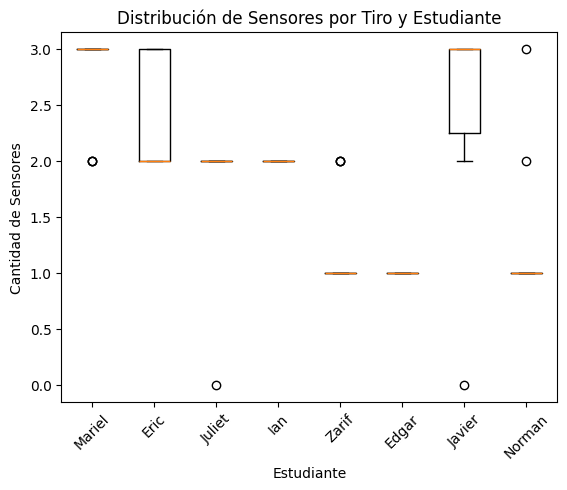

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# Crear lista de listas por estudiante
data_boxplot = [
    try_sensor_df[try_sensor_df["student"] == s]["cantidad_sensores"]
    for s in try_sensor_df["student"].unique()
]

plt.boxplot(data_boxplot)
plt.xticks(range(1, len(try_sensor_df["student"].unique()) + 1),
           try_sensor_df["student"].unique(),
           rotation=45)

plt.title("Distribución de Sensores por Tiro y Estudiante")
plt.ylabel("Cantidad de Sensores")
plt.xlabel("Estudiante")
plt.show()

Se observan datos con 0 sensores, que se eliminarán por no contener información (Juliet y Javier)

In [ ]:
try_sensor_df["tiro_completo"] = try_sensor_df["cantidad_sensores"].apply(
    lambda x: 1 if x == len(all_sensors) else 0
)

complete_summary = try_sensor_df.groupby("student")["tiro_completo"].sum()

print("Tiros completos por estudiante:")
print(complete_summary)

Tiros completos por estudiante:
student
Edgar      0
Eric       4
Ian        0
Javier     7
Juliet     0
Mariel    14
Norman     1
Zarif      0
Name: tiro_completo, dtype: int64


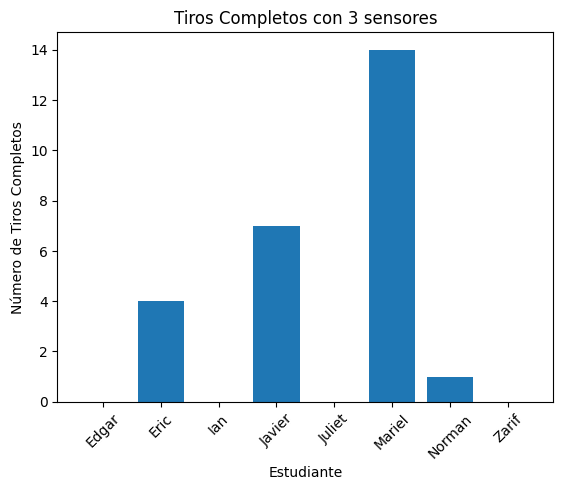

In [ ]:
plt.figure()

plt.bar(complete_summary.index.astype(str),
        complete_summary.values)

plt.title("Tiros Completos con 3 sensores")
plt.ylabel("Número de Tiros Completos")
plt.xlabel("Estudiante")
plt.xticks(rotation=45)
plt.show()

Cantidad de tiros en donde se grabaron con los 3 sensores, la mitad de los estudiantes no cuenta con algún tiro con información de 3 sensores.
Esto es importante para tomar desiciones en el balanceo de clases.

In [ ]:
mean_sensors = summary_student[("cantidad_sensores", "mean")]

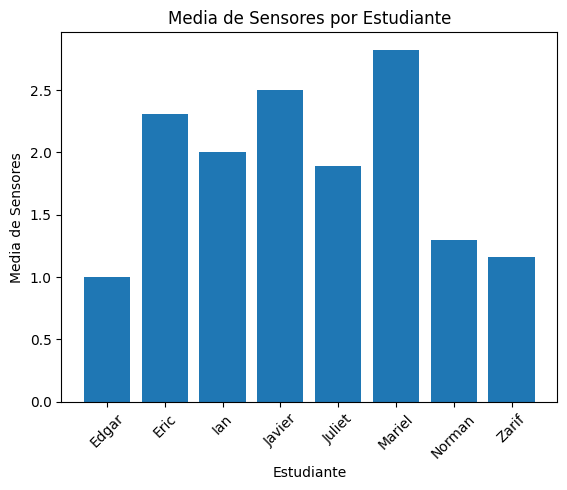

In [ ]:
plt.figure()

plt.bar(mean_sensors.index.astype(str),
        mean_sensors.values)

plt.title("Media de Sensores por Estudiante")
plt.ylabel("Media de Sensores")
plt.xlabel("Estudiante")
plt.xticks(rotation=45)
plt.show()

En promedio, todos tienen por lo menos información de 1 sensor en sus intentos registrados.

### Identificar tiros sin sensores

In [ ]:
# Filtrar tiros sin ningún sensor
no_sensor_shots = try_sensor_df[try_sensor_df["cantidad_sensores"] == 0]

print("Tiros SIN sensores grabados:")
print(no_sensor_shots[["student", "try", "class", "name_file"]])

Tiros SIN sensores grabados:
    student  try  class      name_file
34   Juliet    5      0  Juliet_05.csv
102  Javier   10      1  Javier_10.csv


In [ ]:
# Obtener lista de archivos inválidos
invalid_files = no_sensor_shots["name_file"].tolist()

# Cargar dataset original
data_info = pd.read_csv(data_csv_path)

# Filtrar dataset limpio
data_clean = data_info[~data_info["name_file"].isin(invalid_files)]

print("Dataset original:", len(data_info))
print("Dataset limpio:", len(data_clean))

Dataset original: 111
Dataset limpio: 111


In [ ]:
print("Verificación:")
print(data_clean["name_file"].isin(invalid_files).sum(), "registros inválidos restantes")

Verificación:
0 registros inválidos restantes


In [ ]:
clean_path = "/content/drive/MyDrive/Inercial/data.csv"
data_clean.to_csv(clean_path, index=False)

print("Nuevo archivo limpio guardado en:")
print(clean_path)

Nuevo archivo limpio guardado en:
/content/drive/MyDrive/Inercial/data.csv


### Como balancear

In [ ]:
# Cargar metadata original
data_info = pd.read_csv(data_csv_path)

# Detectar sensores globales reales
files = glob(os.path.join(data_path, "*.csv"))

all_sensors = set()

for f in files:
    df = pd.read_csv(f)
    if "SensorId" in df.columns:
        all_sensors.update(df["SensorId"].dropna().unique())

all_sensors = sorted(list(all_sensors))

print("Sensores detectados globalmente:", all_sensors)

Sensores detectados globalmente: [np.int64(2), np.int64(4), np.int64(5)]


In [ ]:
rows = []

for _, row in data_info.iterrows():

    student = row["student"]
    try_number = row["try"]
    shot_class = row["class"]
    file_name = row["name_file"]

    file_path = os.path.join(data_path, file_name)

    sensores = set()

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        if "SensorId" in df.columns:
            sensores.update(df["SensorId"].dropna().unique())

    rows.append({
        "student": student,
        "try": try_number,
        "class": shot_class,
        "success": 1 if shot_class != 0 else 0,
        "cantidad_sensores": len(sensores)
    })

rebuild_df = pd.DataFrame(rows)

In [ ]:
try_unique_df = (
    rebuild_df
    .groupby(["student", "try"])
    .agg({
        "success": "first",
        "cantidad_sensores": "max"  # max porque puede haber múltiples archivos por tiro
    })
    .reset_index()
)

print("Distribución actual:")
print(try_unique_df["cantidad_sensores"].value_counts())

Distribución actual:
cantidad_sensores
2    45
1    40
3    26
Name: count, dtype: int64


In [ ]:
data_info = pd.read_csv(clean_path)

rows = []

for _, row in data_info.iterrows():

    file_path = os.path.join(data_path, row["name_file"])
    sensores = set()

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        if "SensorId" in df.columns:
            sensores.update(df["SensorId"].dropna().unique())

    rows.append({
        "student": row["student"],
        "try": row["try"],
        "success": 1 if row["class"] != 0 else 0,
        "cantidad_sensores": len(sensores)
    })

verify_df = pd.DataFrame(rows)

verify_unique = (
    verify_df
    .groupby(["student", "try"])
    .agg({
        "success": "first",
        "cantidad_sensores": "max"
    })
    .reset_index()
)

print("Distribución FINAL:")
print(verify_unique["cantidad_sensores"].value_counts())


Distribución FINAL:
cantidad_sensores
2    45
1    40
3    26
Name: count, dtype: int64


In [ ]:
grouped = (
    verify_unique
    .groupby(["cantidad_sensores", "success"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

Este es el resumen de la información del dataset, se segmentó la información por sensor individualmente sin repetición, i.e. Tiros con exclusivamente información de 1 sensor, 2 sensores, 3 sensores sin repetir para todos los intentos.



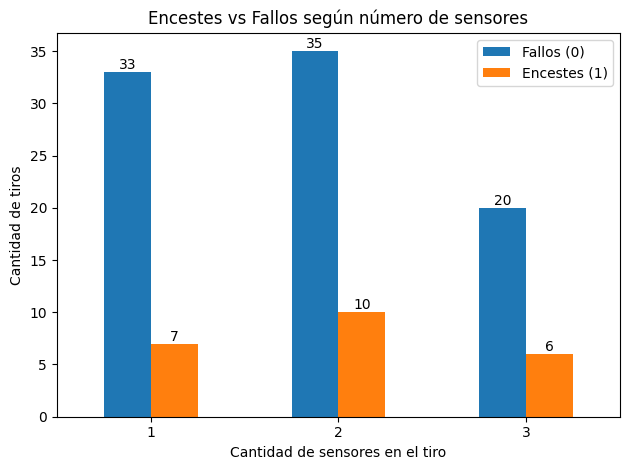

In [ ]:
ax = grouped.plot(kind="bar")

plt.xlabel("Cantidad de sensores en el tiro")
plt.ylabel("Cantidad de tiros")
plt.title("Encestes vs Fallos según número de sensores")
plt.xticks(rotation=0)
plt.legend(["Fallos (0)", "Encestes (1)"])

# Agregar valores encima de las barras
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## Estrategias de Balanceo del Dataset

Se identificó un desbalance estructural tanto por clase (fallo vs enceste) como por número de sensores disponibles.

Distribución actual de la clase minoritaria (encestes):

- 1 sensor → 7
- 2 sensores → 10
- 3 sensores → 6

El límite de balance sin generación sintética lo impone la clase minoritaria:

- 1 sensor → máximo balanceable: 7 vs 7
- 2 sensores → máximo balanceable: 10 vs 10
- 3 sensores → máximo balanceable: 6 vs 6

La tasa de enceste observada es:

- 1 sensor → 17.5%
- 2 sensores → 22.2%
- 3 sensores → 23.1%

---

### Opción 1 — Undersampling

Reducir la clase mayoritaria (fallos) hasta igualar la minoritaria en cada grupo.

Ajustes necesarios:

- 1 sensor → bajar fallos de 33 a 7
- 2 sensores → bajar fallos de 35 a 10
- 3 sensores → bajar fallos de 20 a 6

Resultado final:

- 1 sensor → 7 vs 7
- 2 sensores → 10 vs 10
- 3 sensores → 6 vs 6

Ventajas:
- No se inventan datos.
- Se preserva coherencia física y biomecánica.
- Evita introducir ruido sintético.

Desventajas:
- Se pierde una cantidad considerable de información.
- Disminuye el tamaño total del dataset.
- Puede afectar la capacidad de generalización.

---

### Opción 2 — Oversampling (SMOTE o técnicas similares)

Aumentar la clase minoritaria generando muestras sintéticas dentro de cada grupo de sensores.

Ejemplo de incremento moderado:

- Generar 3 encestes adicionales en grupo 3 sensores
- Generar 3 encestes adicionales en grupo 1 sensor

Ventajas:
- No se descartan datos reales.
- Mantiene tamaño del dataset.
- Mejora la capacidad del modelo para aprender patrones minoritarios.

Desventajas:
- Puede introducir ruido artificial.
- Riesgo de generar patrones no físicamente plausibles.
- SMOTE estándar no siempre es ideal para series temporales IMU.

---

### Opción 3 — Balance Híbrido

Balance parcial

Ejemplo razonable:

#### 1 sensor
- Reducir fallos de 33 → 20  
- Aumentar encestes de 7 → 14  

Resultado: 20 vs 14 (mucho más equilibrado)

#### 2 sensores
- Reducir fallos de 35 → 22  
- Aumentar encestes de 10 → 18  

Resultado: 22 vs 18

#### 3 sensores
- Reducir fallos de 20 → 15  
- Aumentar encestes de 6 → 12  

Resultado: 15 vs 12

No es 1:1, pero ya no es 4:1.

---



## Sensores

In [ ]:
# Tomar 1 ejemplo

files = glob(os.path.join(data_path, "*.csv"))
sample_files = files[:1]

for f in sample_files:
    print("\n==============================")
    print("Archivo:", os.path.basename(f))
    df = pd.read_csv(f)
    print("Columnas:")
    print(df.columns)
    print("\nPrimeras 2 filas:")
    display(df.head(2))


Archivo: Mariel_01.csv
Columnas:
Index(['SensorId', ' TimeStamp (s)', ' FrameNumber', ' AccX (g)', ' AccY (g)',
       ' AccZ (g)', ' GyroX (deg/s)', ' GyroY (deg/s)', ' GyroZ (deg/s)',
       ' MagX (uT)', ' MagY (uT)', ' MagZ (uT)', ' EulerX (deg)',
       ' EulerY (deg)', ' EulerZ (deg)', ' QuatW', ' QuatX', ' QuatY',
       ' QuatZ', ' LinAccX (g)', ' LinAccY (g)', ' LinAccZ (g)',
       ' Pressure (kPa)', ' Altitude (m)', ' Temperature (degC)',
       ' HeaveMotion (m)'],
      dtype='object')

Primeras 2 filas:


,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),MagX (uT),...,QuatX,QuatY,QuatZ,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m)
0,4,0.00,0,0.231569,1.055345,-0.527586,118.630119,67.750877,230.197601,-34.463608,...,0.0,0.0,0.0,-0.169744,0.316244,0.084618,101.521004,-16.303003,39.259998,0.0
1,4,0.01,1,0.221655,1.130493,-0.543380,138.806961,93.046181,247.326752,-34.463608,...,0.0,0.0,0.0,-0.156804,0.242307,0.182916,101.521004,-16.303003,39.259998,0.0


Se cuenta con un csv con la información sobre la clasificación de los tiros, principalmente la clase (0,1).

In [ ]:
data_info = pd.read_csv(data_csv_path)

print("Dimensiones:", data_info.shape)
print("\nColumnas:")
print(data_info.columns)


Dimensiones: (111, 4)

Columnas:
Index(['student', 'class', 'try', 'name_file'], dtype='object')


In [ ]:
students = data_info["student"].unique()
print("Número de estudiantes:", len(students))
print("Lista estudiantes:")
print(students)

Número de estudiantes: 8
Lista estudiantes:
['Mariel' 'Eric' 'Juliet' 'Ian' 'Zarif' 'Edgar' 'Javier' 'Norman']


In [ ]:
class_counts = data_info["class"].value_counts().sort_index()
print("Distribución de clases:")
print(class_counts)

Distribución de clases:
class
0    88
1    19
2     4
Name: count, dtype: int64



Porcentaje por clase:
success
0    79.279279
1    20.720721
Name: proportion, dtype: float64


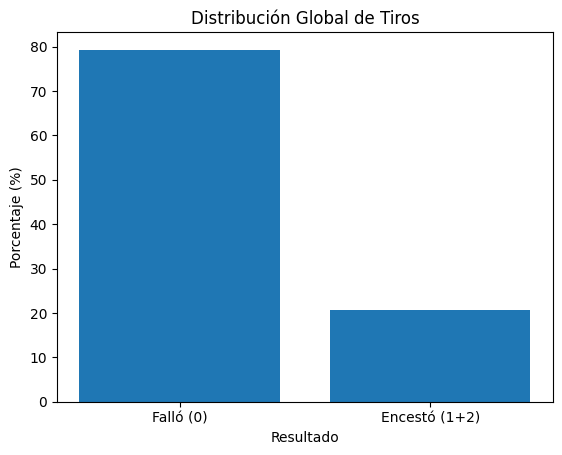

In [ ]:
# Crear variable binaria
data_info["success"] = data_info["class"].apply(lambda x: 0 if x == 0 else 1)

class_percent = data_info["success"].value_counts(normalize=True).sort_index() * 100

print("\nPorcentaje por clase:")
print(class_percent)

plt.figure()
plt.bar(["Falló (0)", "Encestó (1+2)"], class_percent.values)
plt.title("Distribución Global de Tiros")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Resultado")
plt.show()

Después de la limpieza de datos sin información de ningún sensor, se obtuvo una división de aproximadamente (class 0:80% y class 1:20%)


Estadísticas por estudiante:
         Encestes  Intentos  Porcentaje_Enceste
student                                        
Ian             4        10           40.000000
Norman          4        10           40.000000
Javier          3         9           33.333333
Eric            3        13           23.076923
Edgar           3        16           18.750000
Mariel          3        17           17.647059
Juliet          2        17           11.764706
Zarif           1        19            5.263158


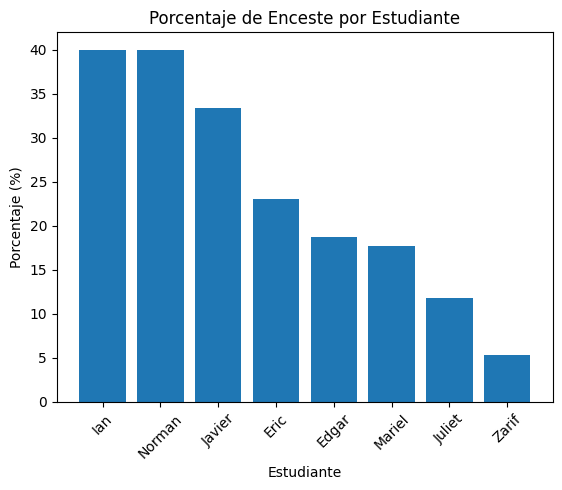

In [ ]:
# Total encestes por estudiante
student_success = data_info.groupby("student")["success"].sum()

# Total intentos por estudiante
student_total = data_info.groupby("student")["success"].count()

# Porcentaje de enceste
student_rate = (student_success / student_total) * 100

student_stats = pd.DataFrame({
    "Encestes": student_success,
    "Intentos": student_total,
    "Porcentaje_Enceste": student_rate
})

student_stats = student_stats.sort_values("Porcentaje_Enceste", ascending=False)

print("\nEstadísticas por estudiante:")
print(student_stats)

plt.figure()
plt.bar(student_stats.index.astype(str), student_stats["Porcentaje_Enceste"])
plt.xticks(rotation=45)
plt.title("Porcentaje de Enceste por Estudiante")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Estudiante")
plt.show()

Solo para ver el ranking de tiro.

In [ ]:
data_info = pd.read_csv(data_csv_path)

data_info["class"] = data_info["class"].replace(2, 1)

print("Clases después de convertir 2 → 1:")
print(data_info["class"].value_counts())

clean_path = "/content/drive/MyDrive/Inercial/data.csv"
data_info.to_csv(clean_path, index=False)

print("Dataset binario guardado en:")
print(clean_path)

Clases después de convertir 2 → 1:
class
0    88
1    23
Name: count, dtype: int64
Dataset binario guardado en:
/content/drive/MyDrive/Inercial/data.csv


Se contaba con una tercera clase (class = 2, indicaba si el tiro entró sin tocar el aro), pero solo se contaban con 4 tiros así, muy pocos para hacer aún mas una tercera categoría.

---

# 02 Procesamiento

    Analizar la implementación de filtros para eliminar ruido y segmentación para aislar el evento del tiro.

    Definición de la frecuencia de muestreo y selección estratégica de los tipos de señales disponibles, e.g., aceleración total.


## Estructura del Dataset

## Tiempo

| Columna | Tipo | Descripción |
|----------|------|-------------|
| SensorId | Categórica | Identificador del sensor (2=Mano, 5=Antebrazo, 4=Bíceps) |
| TimeStamp (s) | Continua | Tiempo en segundos |
| FrameNumber | Entero | Índice secuencial de muestra |

---

## Señales Inerciales (RAW)

| Columna | Unidad | Qué mide |
|----------|--------|----------|
| AccX, AccY, AccZ | g | Aceleración total (incluye gravedad) |
| GyroX, GyroY, GyroZ | deg/s | Velocidad angular |
| MagX, MagY, MagZ | µT | Campo magnético |

---

## Orientación

| Columna | Unidad | Descripción |
|----------|--------|------------|
| EulerX, EulerY, EulerZ | grados | Roll, Pitch, Yaw |
| QuatW, QuatX, QuatY, QuatZ | adimensional | Orientación en cuaterniones |

---

## Señales Derivadas

| Columna | Unidad | Descripción |
|----------|--------|------------|
| LinAccX, LinAccY, LinAccZ | g | Aceleración sin gravedad |
| Pressure | kPa | Presión barométrica |
| Altitude | m | Altitud estimada |
| Temperature | °C | Temperatura interna |
| HeaveMotion | m | Desplazamiento vertical estimado |

---

Observaciones:

- `TimeStamp` incrementa en pasos de 0.01 s, es una frecuencia ≈ 100 Hz.
- `GyroZ` muestra incremento progresivo a fase inicial de rotación.

El movimiento principal se detecta en aceleraciones lineales y giroscopio.


---

## Filtrado

Se aplicar únicamente:

### Filtro Pasa-Bajas
- Tipo: Butterworth 4º orden
- Corte: 15–20 Hz
- Aplicar a:
  - LinAcc
  - Gyro

Justificación:
El lanzamiento humano tiene contenido principal < 15 Hz.

No filtrar presión ni temperatura.

---

### Señales Principales

| Señal | Motivo |
|--------|--------|
| LinAccX, LinAccY, LinAccZ | Movimiento real sin gravedad |
| GyroX, GyroY, GyroZ | Dinámica rotacional |
| Quaternions | Orientación estable |

---

### Señales Secundarias

| Señal | Uso |
|--------|------|
| AccX, AccY, AccZ | Calcular magnitud total |
| Pressure | Detectar posible fase aérea |

---

### Señales a ignorar

| Señal | Motivo |
|--------|--------|
| Magnetómetro | Interferencia en cancha |
| Temperature | Sin impacto biomecánico |
| Altitude | Derivada ruidosa |
| HeaveMotion | Señal derivada acumulativa |

---

# Segmentación del Evento de Tiro


1. Calcular magnitud de aceleración lineal:

   ||a|| = sqrt(LinAccX² + LinAccY² + LinAccZ²)

2. Detectar el pico máximo.
3. Extraer ventana:
   - 40–50 muestras antes
   - 40–50 muestras después

A 100 Hz:
- Ventana total ≈ 0.8–1.0 segundos

Esto encapsula:
- Preparación
- Liberación
- Seguimiento

---

# 5. Selección Estratégica Final

Base del modelo:

Sensores:
- Antebrazo (5)
- Mano (2)

Señales finales recomendadas por sensor:

- 3 ejes LinAcc
- 3 ejes Gyro
- 4 componentes Quaternion

Total por sensor: 10 variables.

Si usas 2 sensores:
- 20 variables por timestep.

---

# 6. Pipeline Recomendado

1. Filtrar LinAcc y Gyro.
2. Detectar pico automático.
3. Recortar ventana fija.
4. Normalizar por tiro (z-score).
5. Entrenar con class weights.

Enfoque mínimo, estable y biomecánicamente coherente.

## EDA

,student,cantidad_sensores,class,name_file,sensor_ids
6,Edgar,1,1,Edgar_07.csv,[5]
85,Norman,1,0,Norman_04.csv,[2]
18,Eric,2,1,Erick_03.csv,"[2, 5]"
29,Ian,2,0,Ian_01.csv,"[2, 5]"
41,Javier,3,1,Javier_03.csv,"[2, 4, 5]"
65,Mariel,3,0,Mariel_01.csv,"[2, 4, 5]"


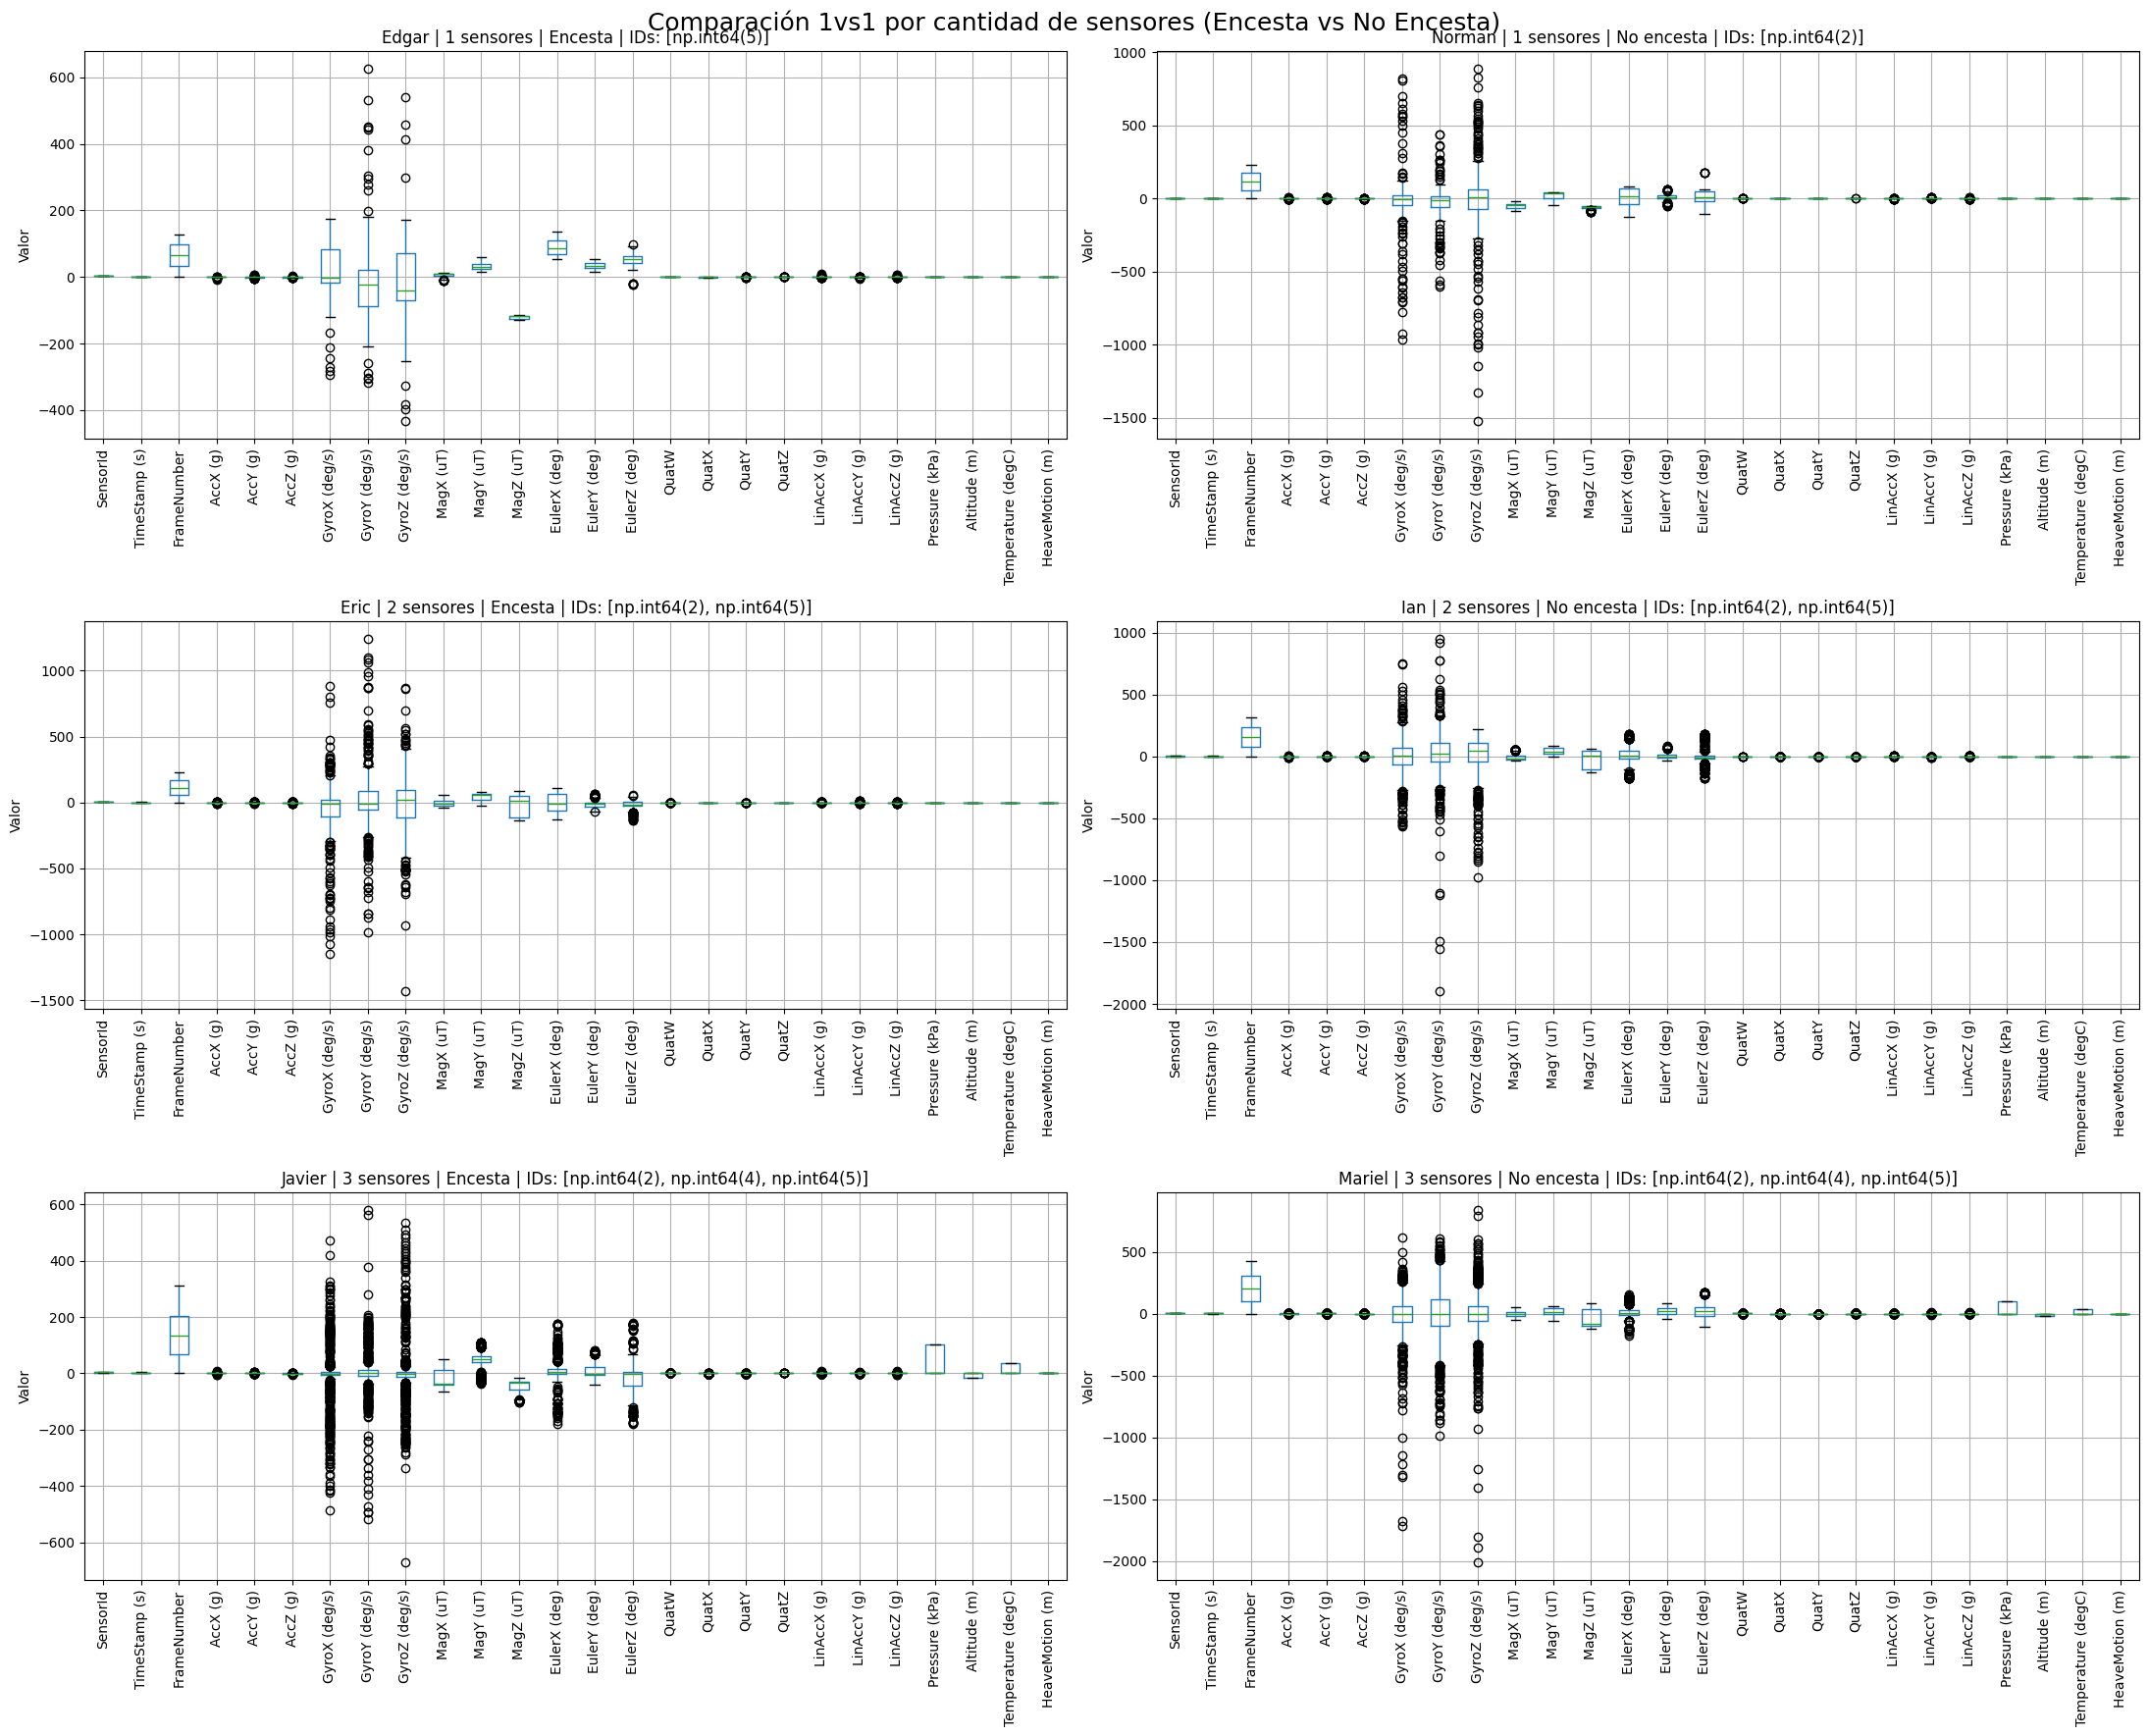

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==============================
# 1. Leer dataset con clases
# ==============================
data_info = pd.read_csv(data_csv_path)

# ==============================
# 2. Contar cantidad de sensores por tiro e identificar IDs
# ==============================
rows = []

for _, row in data_info.iterrows():
    file_path = os.path.join(data_path, row["name_file"])
    sensores = set()

    if os.path.exists(file_path):
        df_temp = pd.read_csv(file_path)
        df_temp.columns = df_temp.columns.str.strip()
        if "SensorId" in df_temp.columns:
            sensores.update(df_temp["SensorId"].dropna().unique())

    rows.append({
        "student": row["student"],
        "try": row["try"],
        "class": 1 if row["class"] > 0 else 0,  # solo 0 y 1
        "name_file": row["name_file"],
        "cantidad_sensores": len(sensores),
        "sensor_ids": list(sensores)
    })

try_df = pd.DataFrame(rows)

# Agrupar por tiro único
try_unique = (
    try_df
    .groupby(["student", "try"])
    .agg({
        "class": "first",
        "name_file": "first",
        "cantidad_sensores": "max",
        "sensor_ids": "first"
    })
    .reset_index()
)

# ==============================
# 3. Seleccionar 6 tiros: 1 vs 1 por sensores
# ==============================
selected = []
used_students = set()

for sensors in [1, 2, 3]:
    # Encesta
    enceste = try_unique[
        (try_unique["cantidad_sensores"] == sensors) &
        (try_unique["class"] == 1) &
        (~try_unique["student"].isin(used_students))
    ]
    if not enceste.empty:
        selected.append(enceste.iloc[0])
        used_students.add(enceste.iloc[0]["student"])

    # Fallo
    fallo = try_unique[
        (try_unique["cantidad_sensores"] == sensors) &
        (try_unique["class"] == 0) &
        (~try_unique["student"].isin(used_students))
    ]
    if not fallo.empty:
        selected.append(fallo.iloc[0])
        used_students.add(fallo.iloc[0]["student"])

# ==============================
# 4. Mostrar información de los seleccionados
# ==============================
selected_df = pd.DataFrame(selected)
display(selected_df[["student", "cantidad_sensores", "class", "name_file", "sensor_ids"]])

# ==============================
# 5. Graficar grid 3x2 boxplots
# ==============================
fig, axes = plt.subplots(3, 2, figsize=(22, 18))
axes = axes.flatten()

for ax, row in zip(axes, selected):
    file_path = os.path.join(data_path, row["name_file"])
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    numeric_df = df.select_dtypes(include=[np.number])

    numeric_df.boxplot(ax=ax, rot=90)

    ax.set_title(
        f'{row["student"]} | {row["cantidad_sensores"]} sensores | '
        f'{"Encesta" if row["class"]==1 else "No encesta"} | IDs: {row["sensor_ids"]}'
    )
    ax.set_ylabel("Valor")

# Apagar ejes sobrantes si faltan
for i in range(len(selected), len(axes)):
    axes[i].axis("off")

plt.suptitle("Comparación 1vs1 por cantidad de sensores (Encesta vs No Encesta)", fontsize=18)
plt.tight_layout()
plt.show()

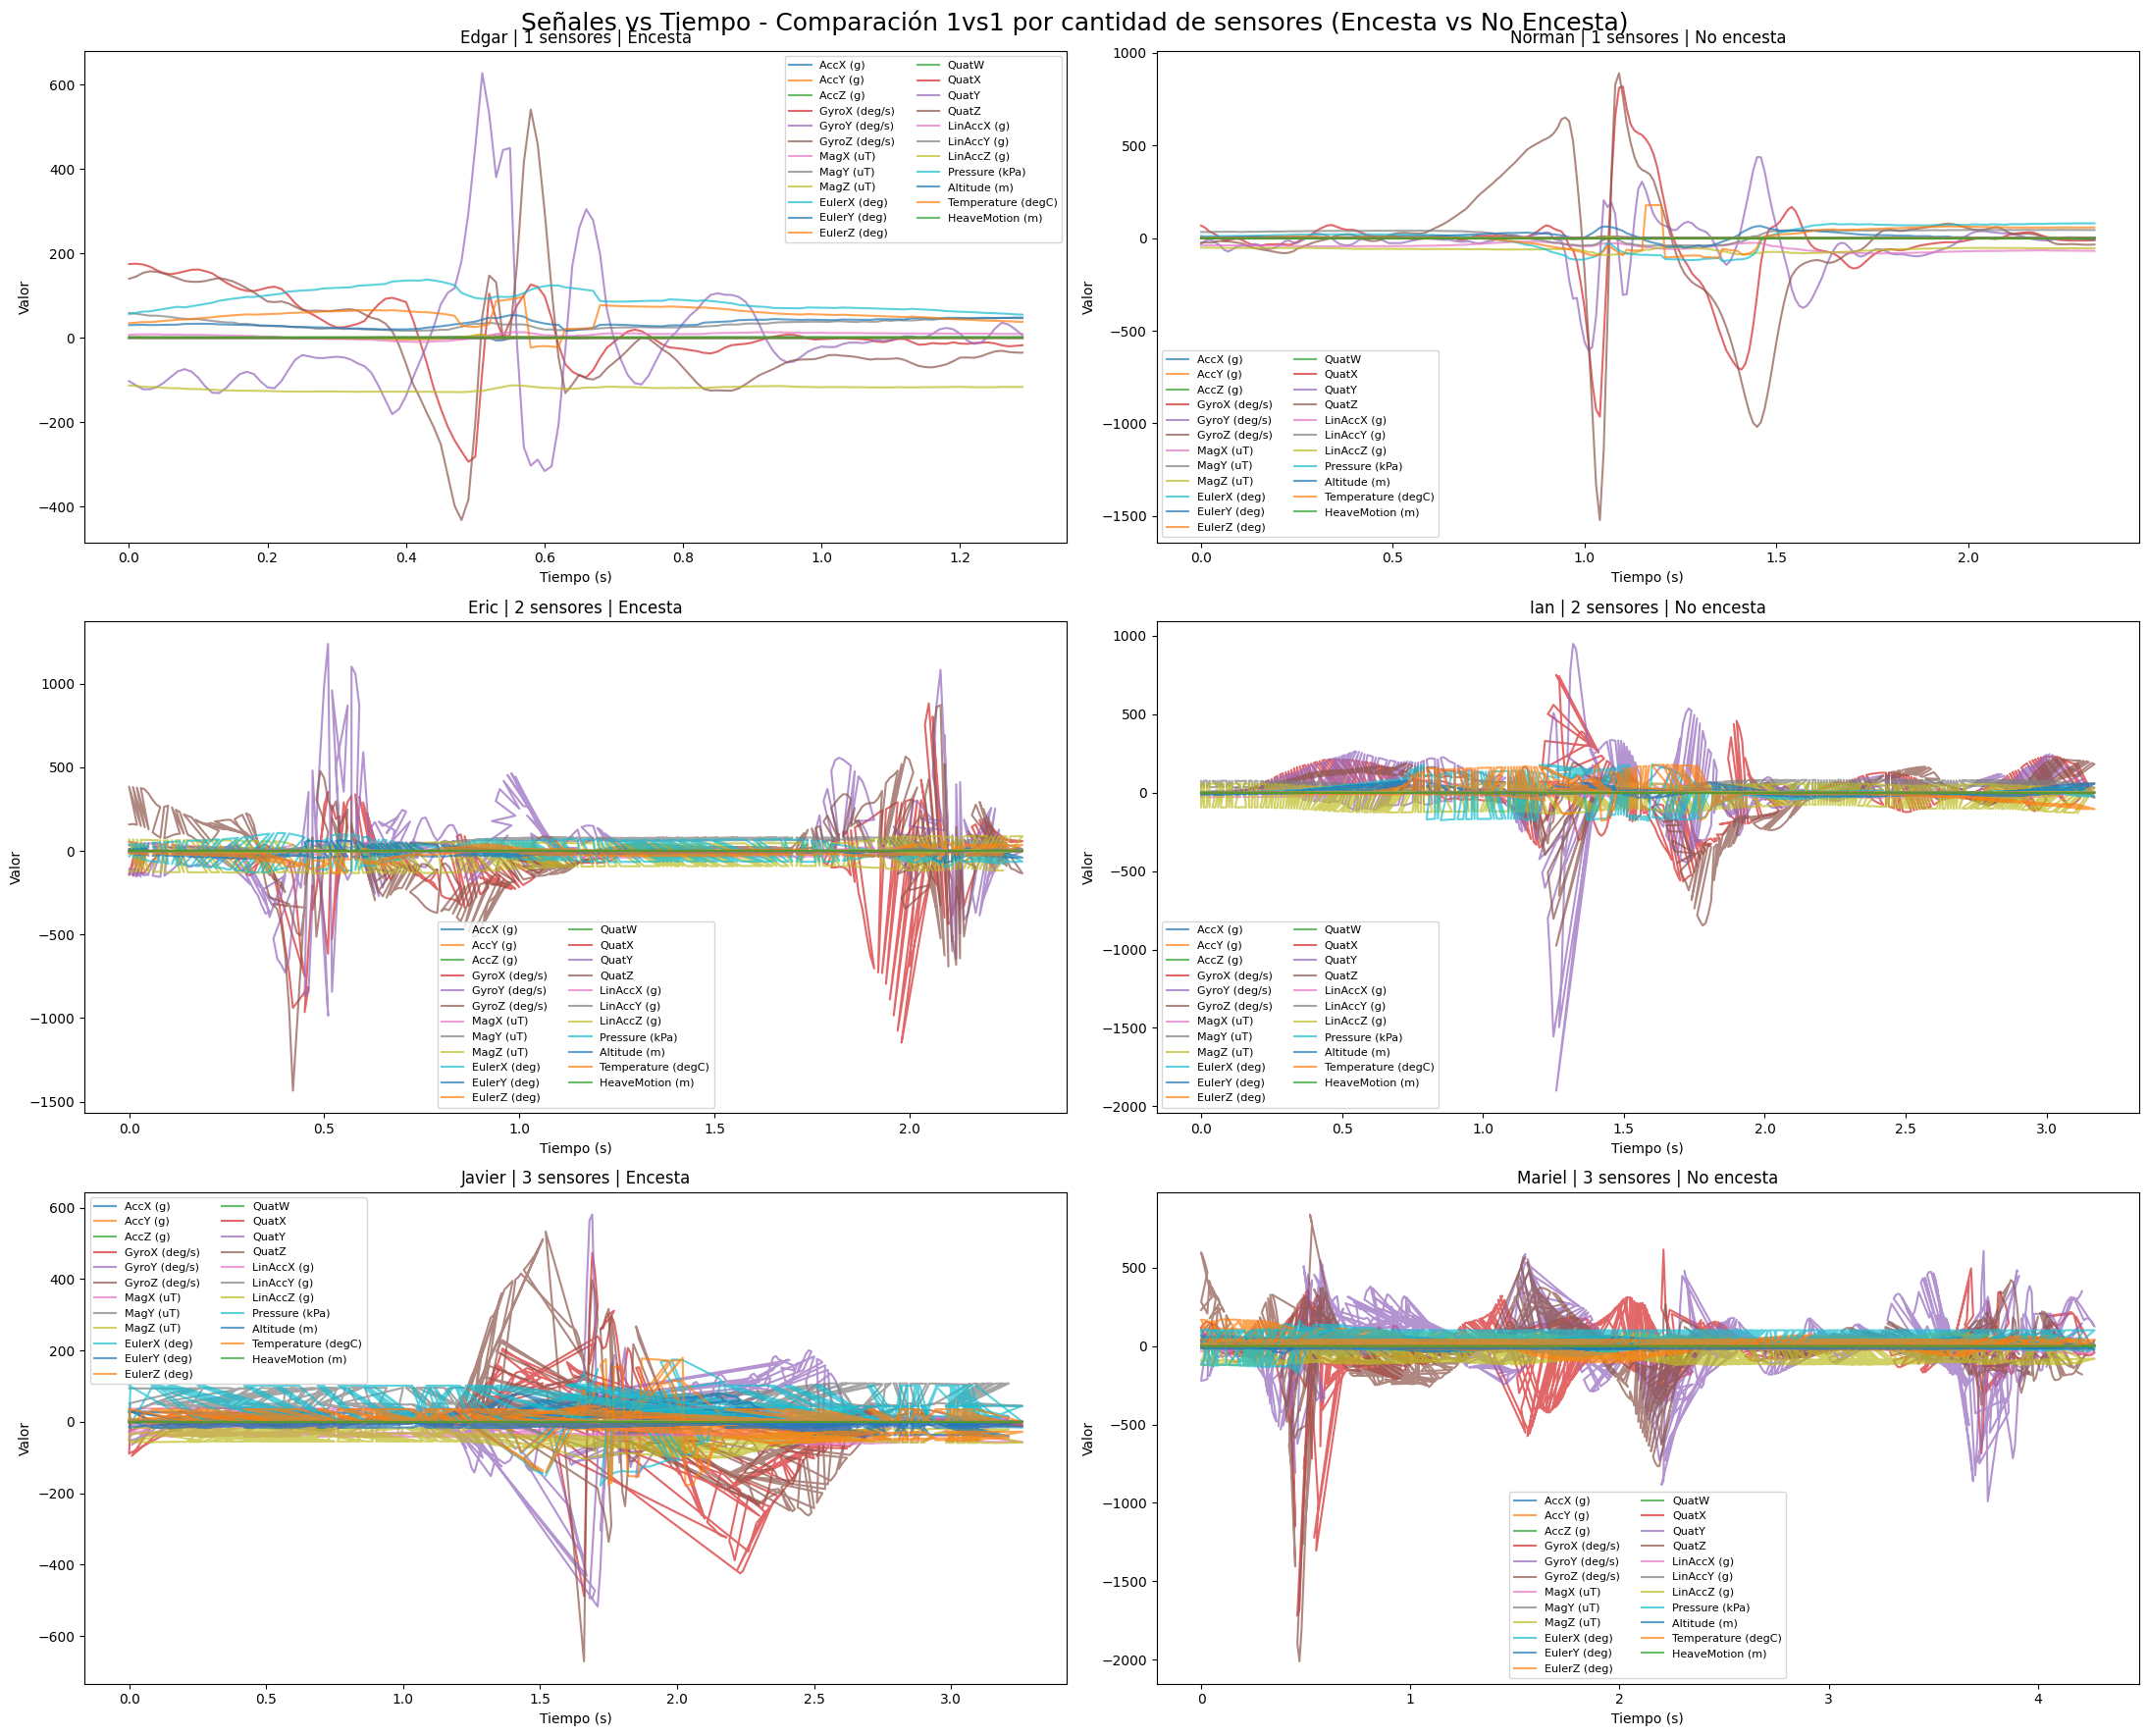

In [24]:
# ==============================
# Graficar señales vs tiempo
# ==============================
fig, axes = plt.subplots(3, 2, figsize=(22, 18))
axes = axes.flatten()

for ax, row in zip(axes, selected):
    file_path = os.path.join(data_path, row["name_file"])
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    # Seleccionar TimeStamp y columnas numéricas
    if "TimeStamp (s)" in df.columns:
        time = df["TimeStamp (s)"]
    else:
        time = df["FrameNumber"]  # fallback

    numeric_df = df.select_dtypes(include=[np.number]).copy()

    # Quitar columnas que no son señales
    for col in ["TimeStamp (s)", "FrameNumber", "SensorId"]:
        if col in numeric_df.columns:
            numeric_df = numeric_df.drop(columns=[col])

    # Graficar cada señal vs tiempo
    for col in numeric_df.columns:
        ax.plot(time, numeric_df[col], alpha=0.7, label=col)

    ax.set_title(f'{row["student"]} | {row["cantidad_sensores"]} sensores | {"Encesta" if row["class"]==1 else "No encesta"}')
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Valor")
    ax.legend(fontsize=8, ncol=2)

# Apagar ejes sobrantes si faltan
for i in range(len(selected), len(axes)):
    axes[i].axis("off")

plt.suptitle("Señales vs Tiempo - Comparación 1vs1 por cantidad de sensores (Encesta vs No Encesta)", fontsize=18)
plt.tight_layout()
plt.show()

- Al **inicio**: Hay un período largo sin movimiento (línea plana con ruido)
- Al **final**: También hay un período sin movimiento relevante
- En el **centro**: Se ven los picos correspondientes a los tiros



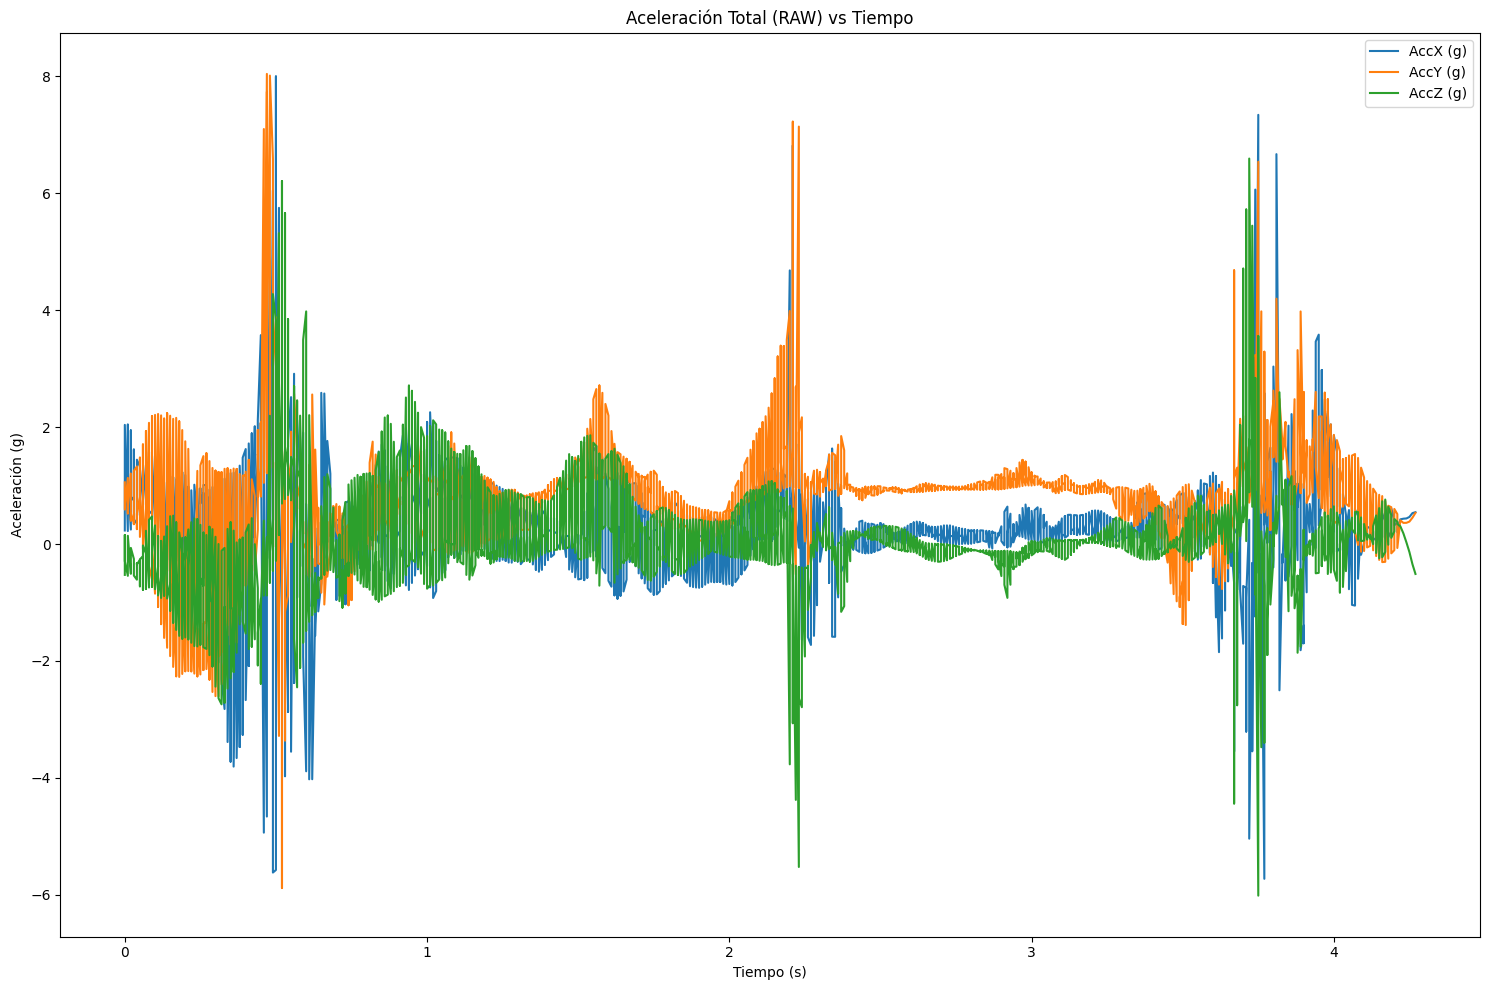

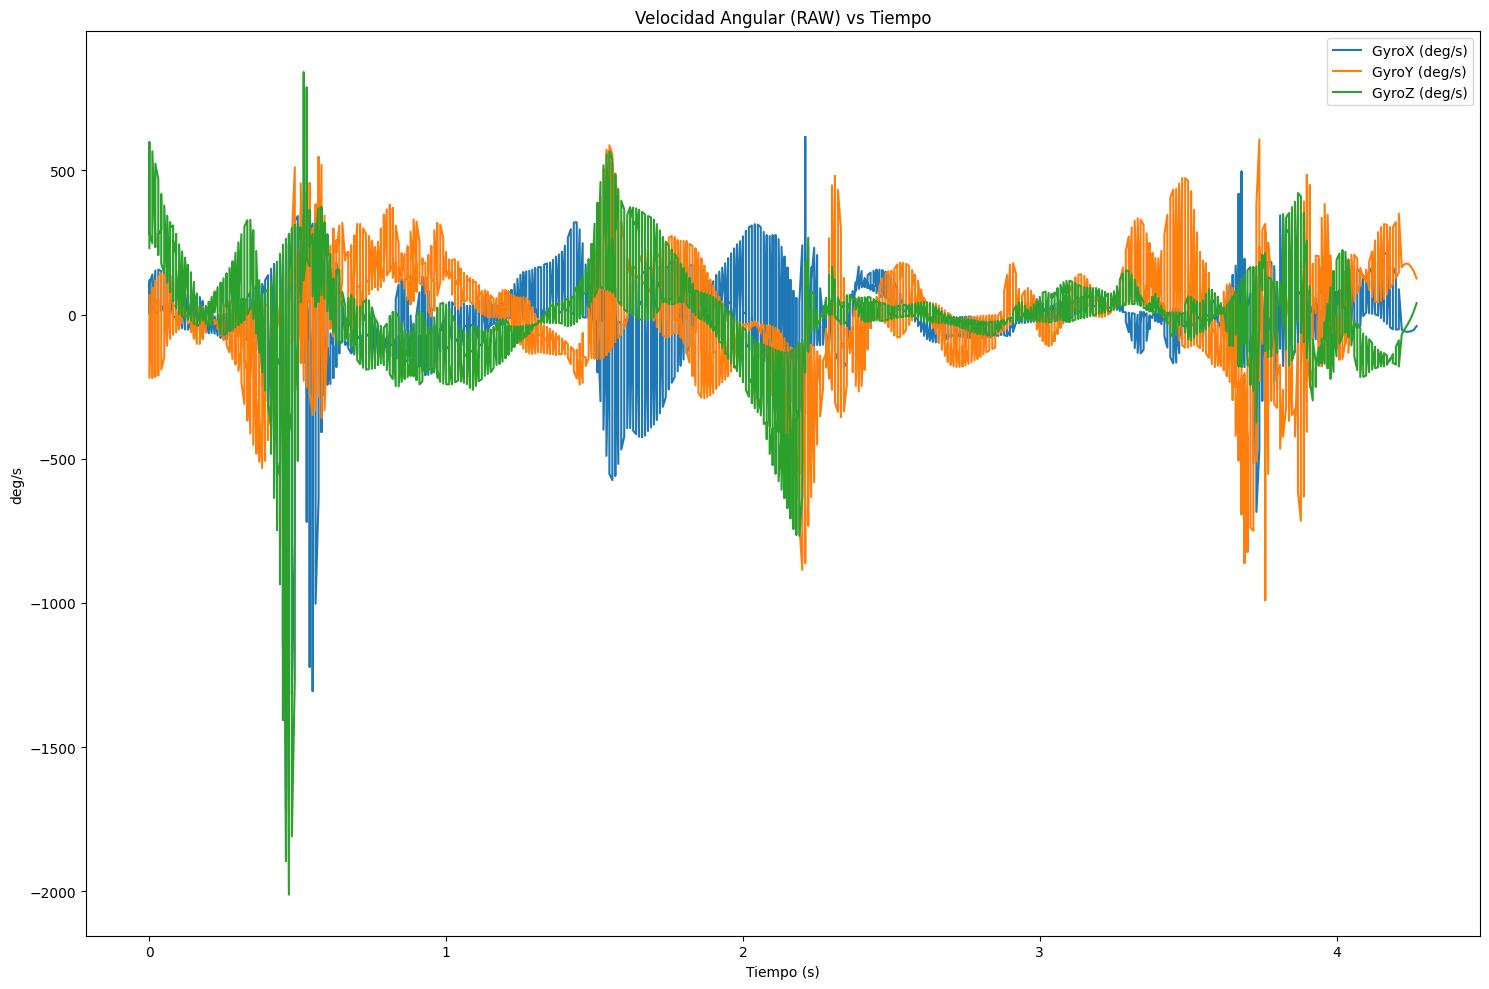

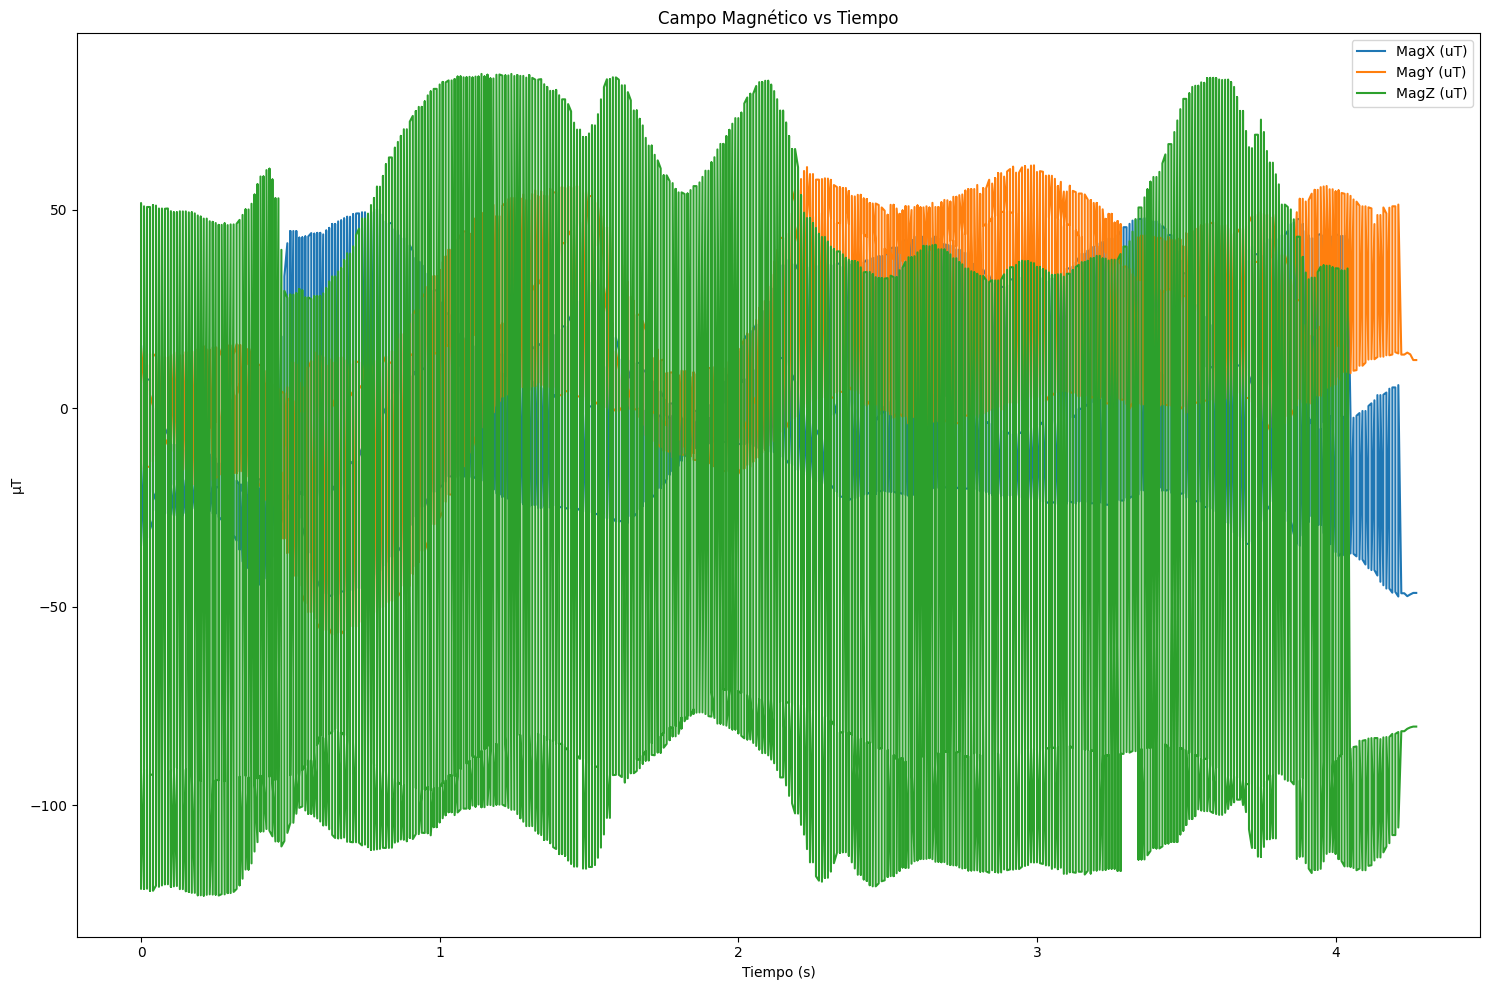

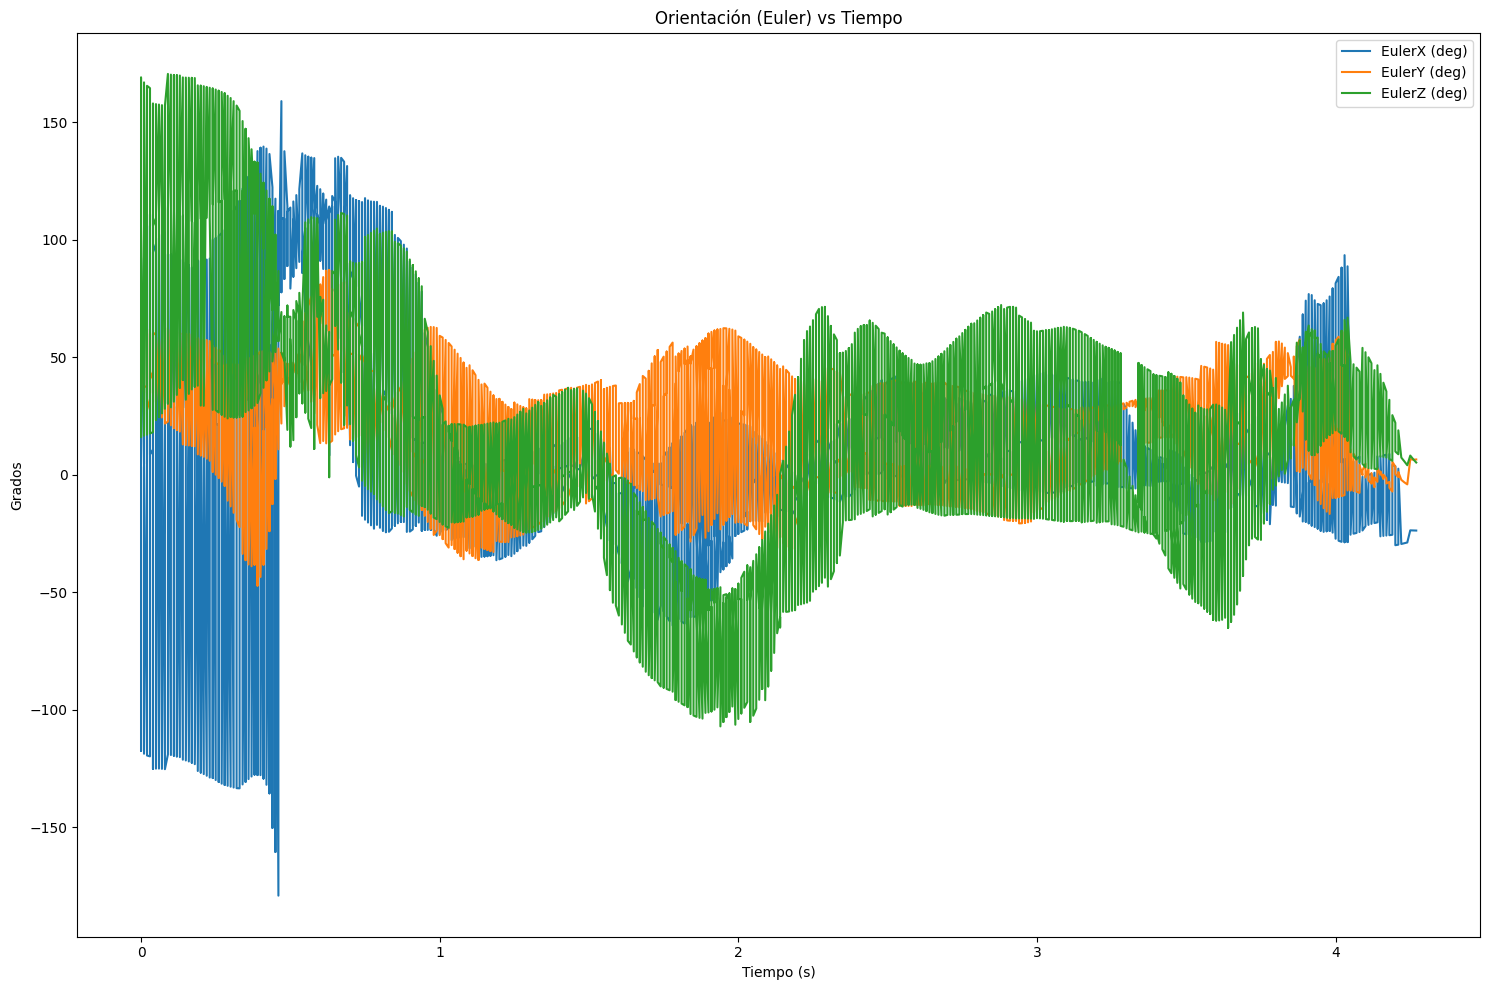

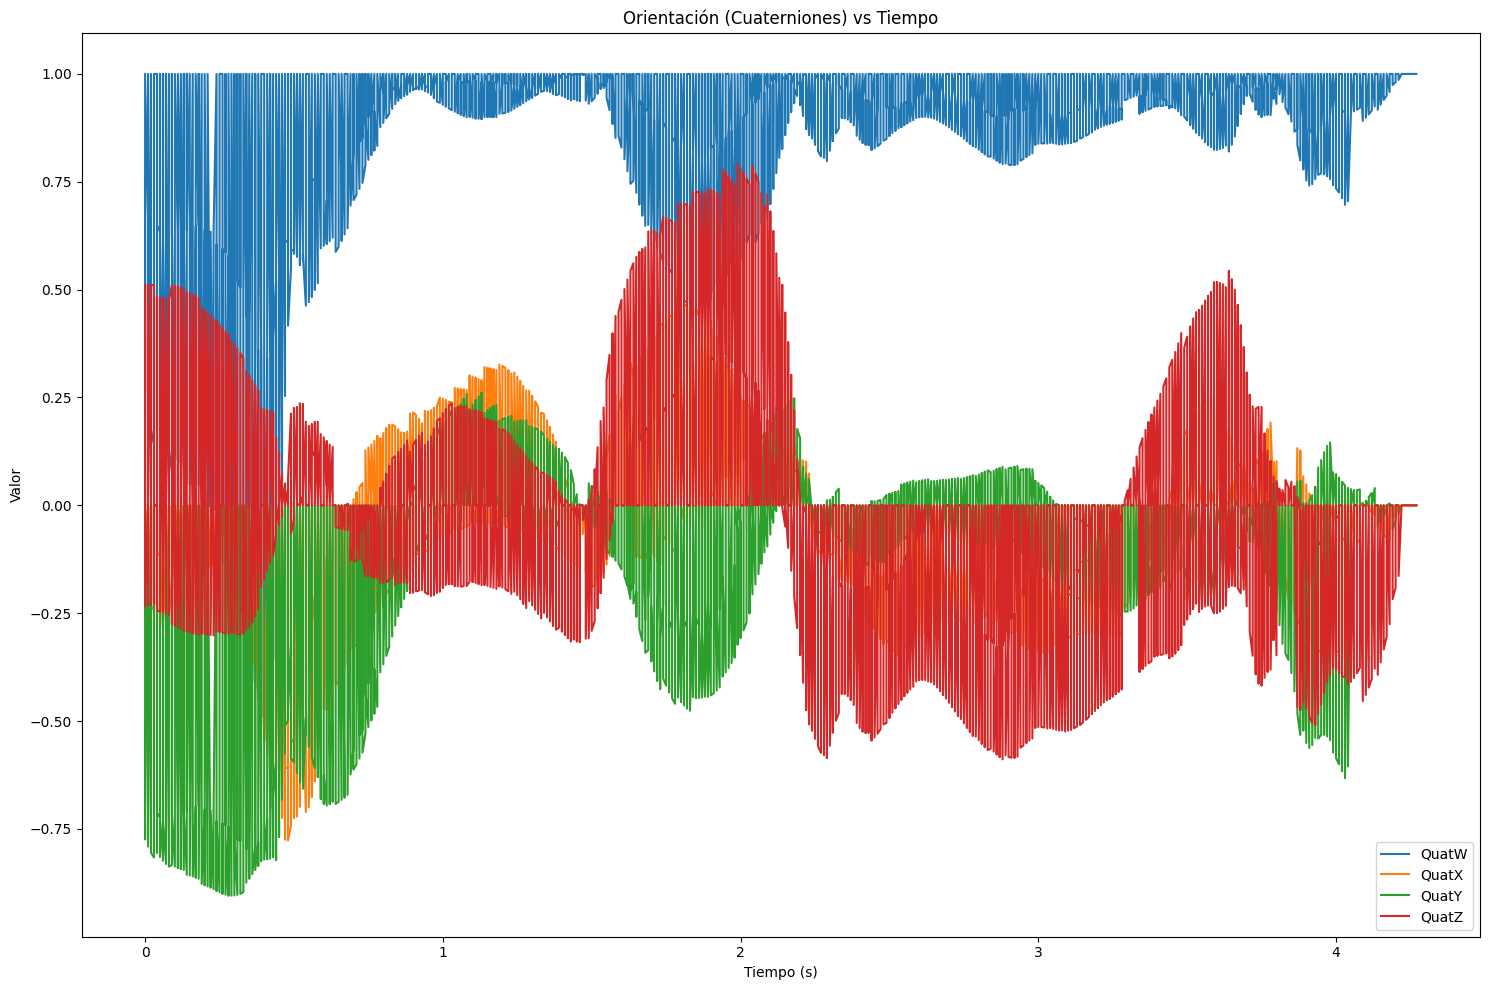

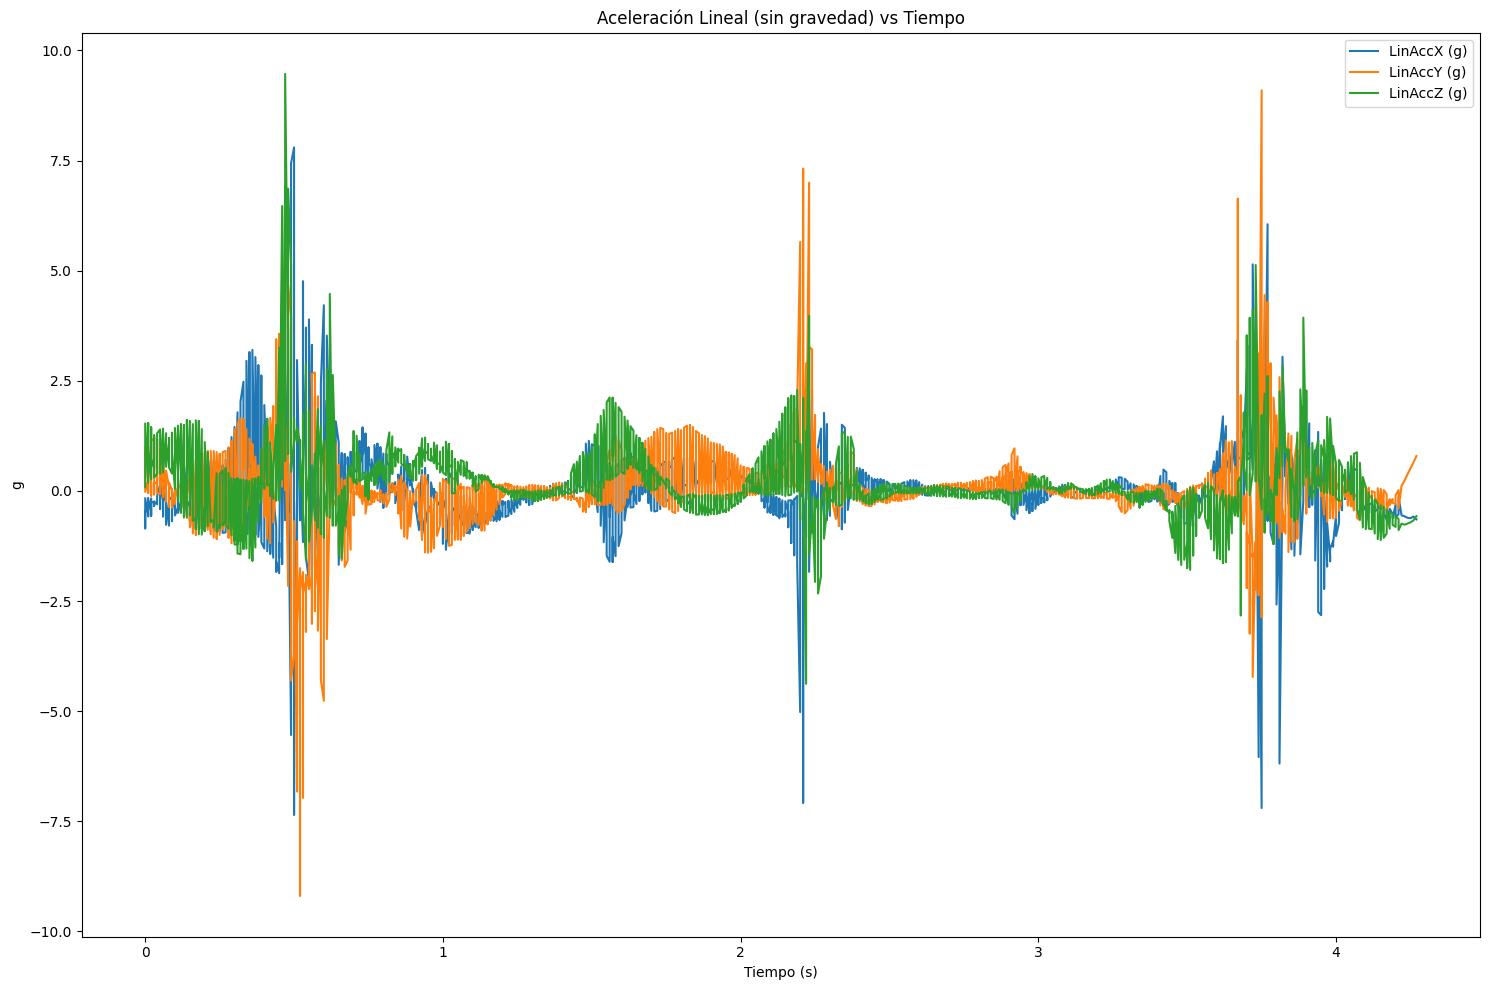

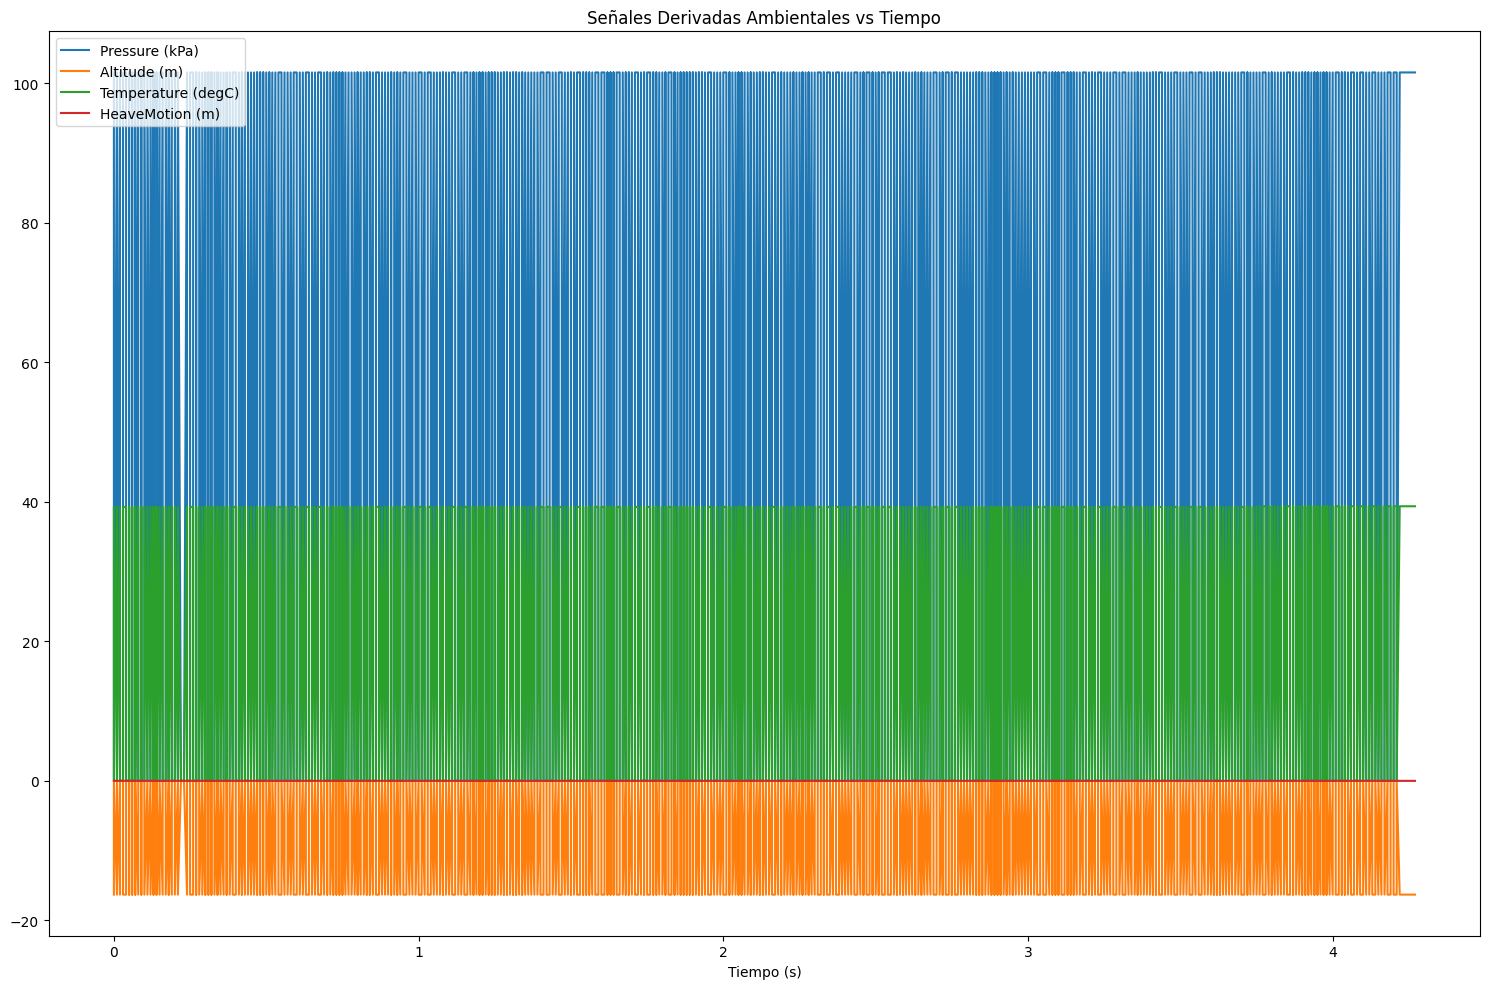

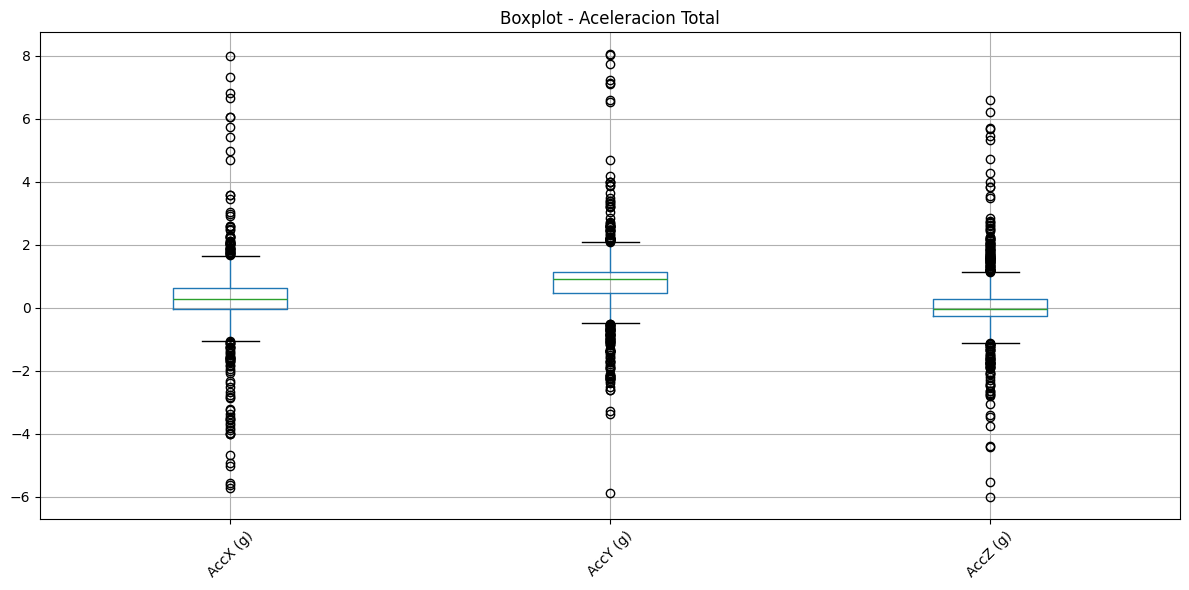

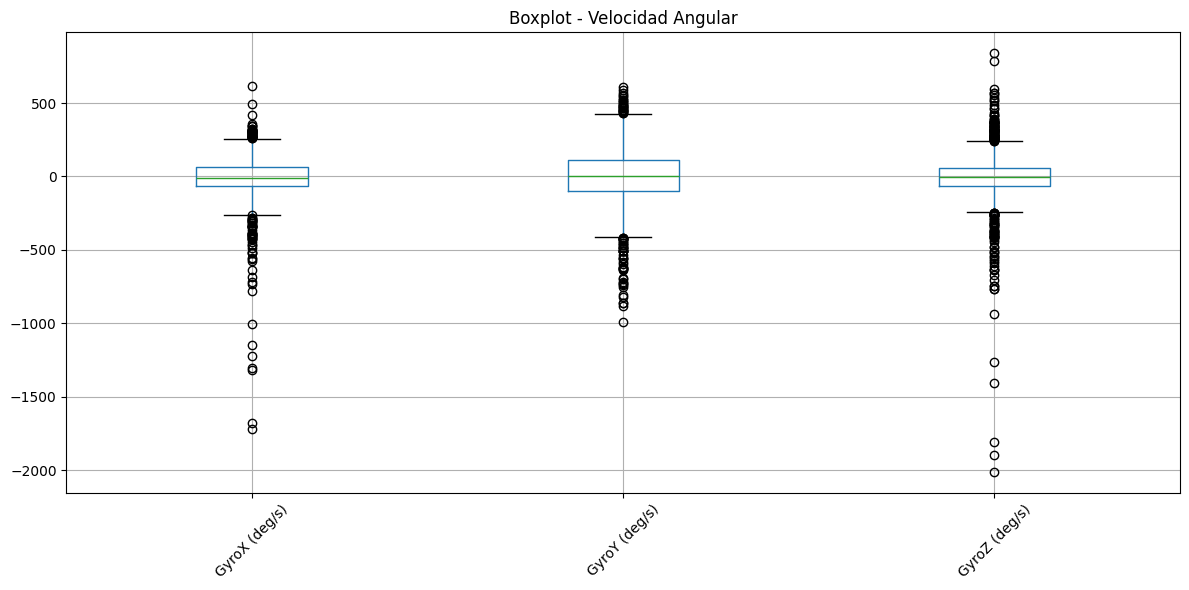

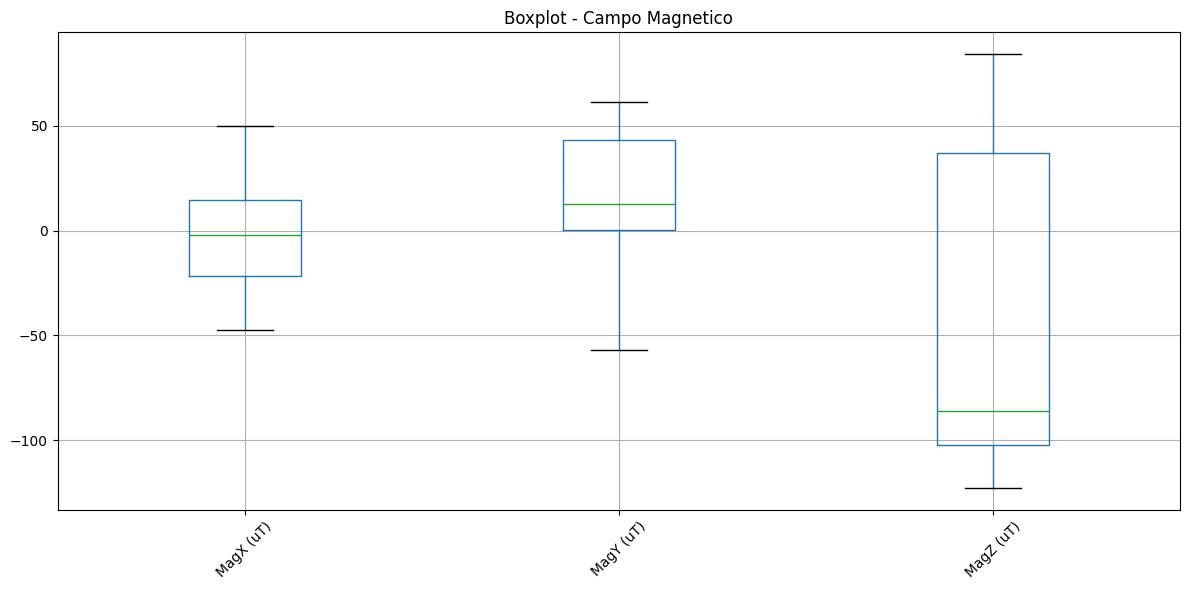

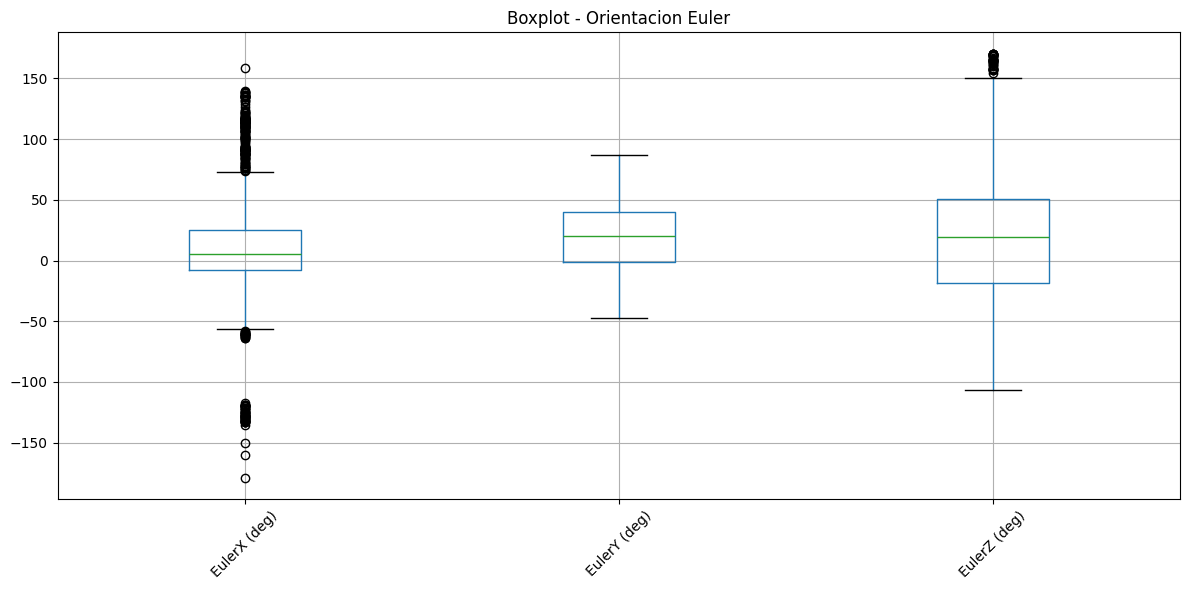

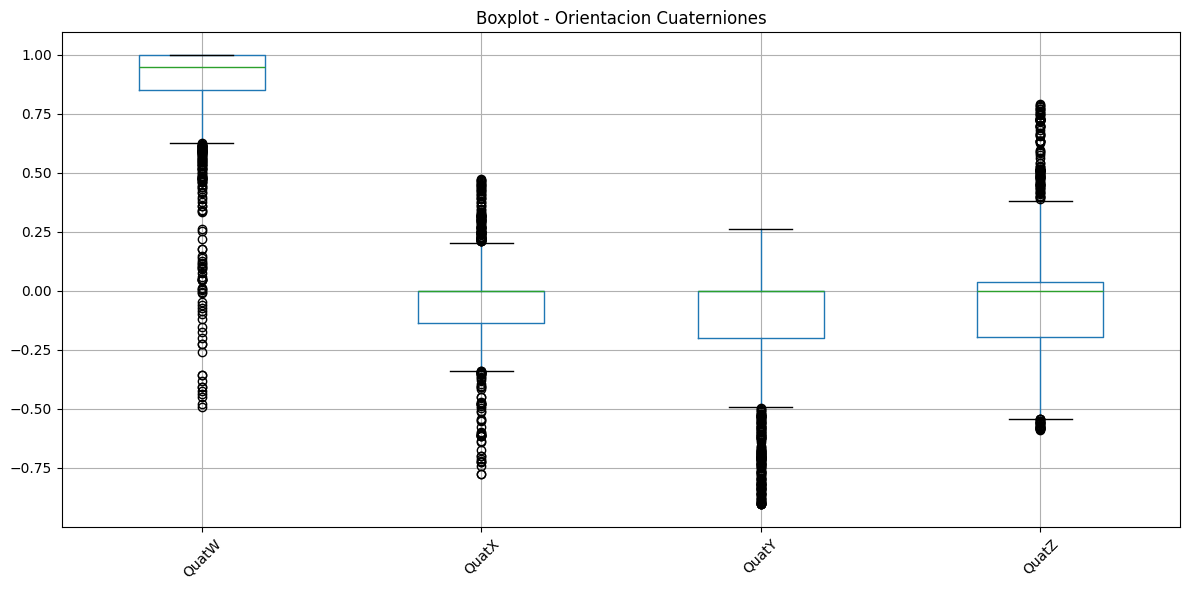

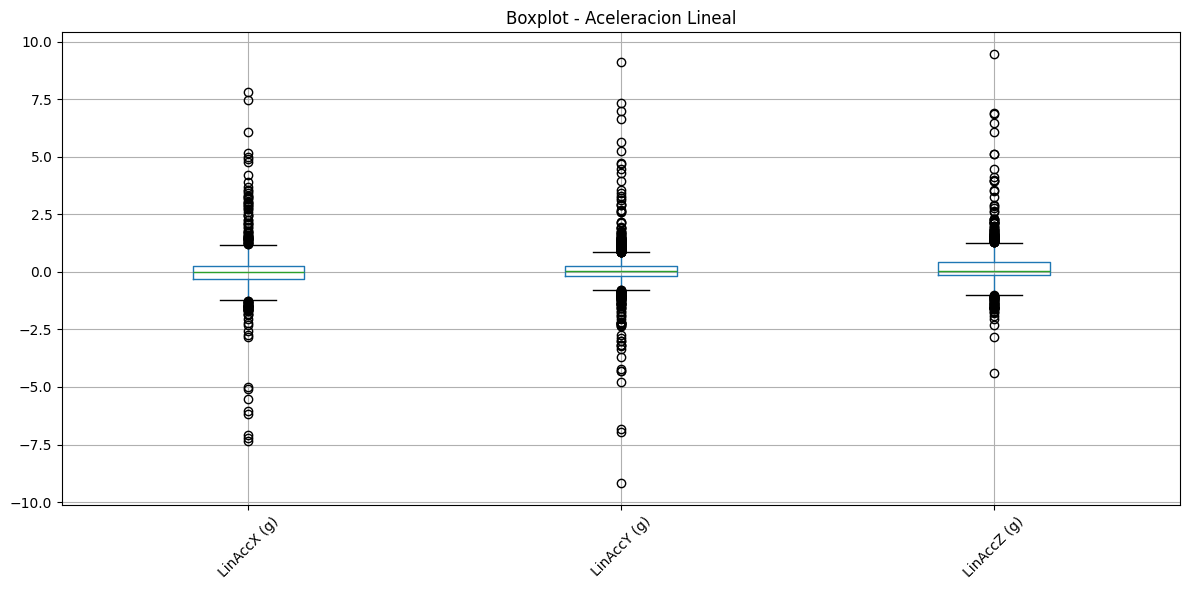

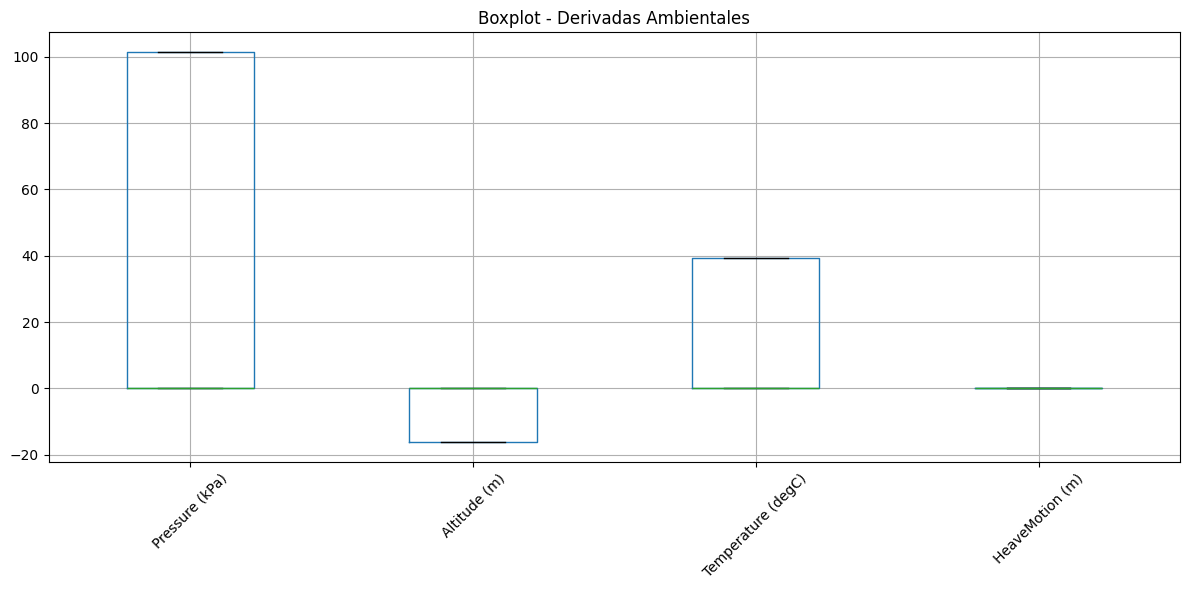


Estadisticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
SensorId,1237.0,3.673403,1.237904,2.000000,2.000000,4.000000,5.000000,5.000000
TimeStamp (s),1237.0,2.079491,1.207436,-0.000000,1.030000,2.080000,3.110000,4.270000
FrameNumber,1237.0,205.780113,119.276684,0.000000,103.000000,206.000000,309.000000,425.000000
AccX (g),1237.0,0.275690,1.067954,-5.724848,-0.045471,0.273614,0.633988,7.996101
AccY (g),1237.0,0.803736,1.031330,-5.883113,0.475200,0.916139,1.121892,8.039588
AccZ (g),1237.0,0.041621,0.954387,-6.012641,-0.273969,-0.033879,0.289272,6.592027
GyroX (deg/s),1237.0,-12.572332,171.695976,-1720.044312,-67.078880,-6.929402,62.535824,616.032776
GyroY (deg/s),1237.0,-1.422551,201.088664,-990.426392,-98.958984,0.220336,112.185364,606.761169
GyroZ (deg/s),1237.0,-11.374434,200.809280,-2011.283081,-62.201237,-4.968276,59.895470,839.495300
MagX (uT),1237.0,-0.566429,25.342219,-47.471500,-21.631102,-2.338497,14.352529,50.102310


In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. CARGAR ARCHIVO
# ==============================

file_path = os.path.join(data_path, "Mariel_01.csv")
df = pd.read_csv(file_path)

# Copia para análisis (no modifica original)
df_analysis = df.copy()
df_analysis.columns = df_analysis.columns.str.strip()

# Asegurar orden temporal
df_analysis = df_analysis.sort_values("TimeStamp (s)")

time = df_analysis["TimeStamp (s)"]

# ==============================
# 2. DEFINIR SECCIONES
# ==============================

raw_acc = ["AccX (g)", "AccY (g)", "AccZ (g)"]
raw_gyro = ["GyroX (deg/s)", "GyroY (deg/s)", "GyroZ (deg/s)"]
raw_mag = ["MagX (uT)", "MagY (uT)", "MagZ (uT)"]

orientation_euler = ["EulerX (deg)", "EulerY (deg)", "EulerZ (deg)"]
orientation_quat = ["QuatW", "QuatX", "QuatY", "QuatZ"]

derived_linacc = ["LinAccX (g)", "LinAccY (g)", "LinAccZ (g)"]
derived_other = ["Pressure (kPa)", "Altitude (m)",
                 "Temperature (degC)", "HeaveMotion (m)"]

# ==============================
# 3. GRAFICAS RAW VS TIEMPO
# ==============================

plt.figure(figsize=(15, 10))

for col in raw_acc:
    plt.plot(time, df_analysis[col], label=col)

plt.title("Aceleración Total (RAW) vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Aceleración (g)")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 10))

for col in raw_gyro:
    plt.plot(time, df_analysis[col], label=col)

plt.title("Velocidad Angular (RAW) vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("deg/s")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 10))

for col in raw_mag:
    plt.plot(time, df_analysis[col], label=col)

plt.title("Campo Magnético vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("µT")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# 4. ORIENTACION VS TIEMPO
# ==============================

plt.figure(figsize=(15, 10))

for col in orientation_euler:
    plt.plot(time, df_analysis[col], label=col)

plt.title("Orientación (Euler) vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Grados")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 10))

for col in orientation_quat:
    plt.plot(time, df_analysis[col], label=col)

plt.title("Orientación (Cuaterniones) vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# 5. SEÑALES DERIVADAS VS TIEMPO
# ==============================

plt.figure(figsize=(15, 10))

for col in derived_linacc:
    plt.plot(time, df_analysis[col], label=col)

plt.title("Aceleración Lineal (sin gravedad) vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("g")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 10))

for col in derived_other:
    plt.plot(time, df_analysis[col], label=col)

plt.title("Señales Derivadas Ambientales vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# 6. BOXPLOTS POR SECCIONES
# ==============================

sections = {
    "Aceleracion Total": raw_acc,
    "Velocidad Angular": raw_gyro,
    "Campo Magnetico": raw_mag,
    "Orientacion Euler": orientation_euler,
    "Orientacion Cuaterniones": orientation_quat,
    "Aceleracion Lineal": derived_linacc,
    "Derivadas Ambientales": derived_other
}

for title, cols in sections.items():
    plt.figure(figsize=(12, 6))
    df_analysis[cols].boxplot(rot=45)
    plt.title(f"Boxplot - {title}")
    plt.tight_layout()
    plt.show()

# ==============================
# 7. ESTADISTICOS GENERALES
# ==============================

print("\nEstadisticos descriptivos:")
display(df_analysis.describe().T)

---

# 03 Extracción de características

    Cálculo de features estadísticos, temporales y espectrales para las señales seleccionadas.

    Integración de características de alto nivel, como orientación en cuaterniones o ángulos de Euler.


04 Evaluación interna

    Entrenamiento de 5 modelos de predicción bajo un esquema de validación cruzada estratificada.

    Reporte del desempeño mediante el F1-Score y análisis de la matriz de confusión del mejor clasificador.

05 Validación externa

    Exportación del mejor modelo y preparación de funciones de preprocesamiento de los datos crudos.

    Implementación de un pipeline de inferencia en el Notebook para nuevos datos siguiendo instrucciones técnicas precisas.